# Dissertation Notebook — Results Pipeline (clean)
### *A Comparative Evaluation of Machine-Learning Imputation Methods and Their Effect on Post-Hoc Explainability in Clinical Prediction Models*

---
## 0 — Set-up, paths and run configuration

In [1]:
import os
import re
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import spearmanr, friedmanchisquare, wilcoxon, rankdata
import statsmodels.api as sm

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score

import shap
from lime.lime_tabular import LimeTabularExplainer

warnings.filterwarnings("ignore")

# ---- Reproducibility: one seed for the whole project ------------------------
RANDOM_STATE = 42
SPLIT_SEED = 42        # Cleveland RQ2 train/test split
VA_SEED = 42           # VA cross-validation and VA explanation models
np.random.seed(RANDOM_STATE)

# ---- Paths ------------------------------------------------------------------
PROJECT_ROOT   = Path.cwd()
DATA_RAW       = PROJECT_ROOT / "data" / "heart_disease"
DATA_CLEAN     = PROJECT_ROOT / "data" / "processed"
DATA_VARIANTS  = PROJECT_ROOT / "data" / "variants"

OUT_ROOT       = PROJECT_ROOT / "outputs_clean"     
OUT_TABLES     = OUT_ROOT / "tables"
OUT_FIGURES    = OUT_ROOT / "figures"

# ---- Run configuration ------------------------------------------------------
# Set to True to skip Step 3.2's imputation loop and read back a previously-generated
# data/imputed/ archive that already matches the current MECHANISMS/RATES/N_REPEATS grid.
REUSE_EXISTING_IMPUTATIONS = True

DATA_IMPUTED = PROJECT_ROOT / "data" / "imputed"

for folder in (DATA_CLEAN, DATA_VARIANTS, DATA_IMPUTED, OUT_TABLES, OUT_FIGURES):
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False,
})

print("Project root :", PROJECT_ROOT)
print("Imputed data :", DATA_IMPUTED, "(reuse =", REUSE_EXISTING_IMPUTATIONS, ")")
print("Outputs      :", OUT_ROOT)

Project root : /Users/tarunsridhara/claude/dishu diss
Imputed data : /Users/tarunsridhara/claude/dishu diss/data/imputed (reuse = True )
Outputs      : /Users/tarunsridhara/claude/dishu diss/outputs_clean


### 0.1 — Data dictionary

In [2]:
COLUMNS = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal",
    "num",   # raw label: 0 = no disease, 1-4 = severity
]

CONTINUOUS  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
FEATURES    = CONTINUOUS + CATEGORICAL          # 13 predictors, this exact order
TARGET      = "target"

PRETTY = {
    "age": "Age", "sex": "Sex", "cp": "Chest pain type",
    "trestbps": "Resting BP", "chol": "Cholesterol", "fbs": "Fasting blood sugar",
    "restecg": "Resting ECG", "thalach": "Max heart rate", "exang": "Exercise angina",
    "oldpeak": "ST depression", "slope": "ST slope", "ca": "Vessels (fluoroscopy)",
    "thal": "Thalassemia scan", "target": "Heart disease",
}

# A recorded 0 here is physiologically impossible => it means "not measured"
IMPOSSIBLE_ZERO = ["chol", "trestbps"]

---
# STEP 1 — Load the data and characterise the missingness  *(Objective O1, Results §4.1)*

## 1.1 — Loader, and the two cleaned subsets

In [3]:
def load_subset(name: str) -> pd.DataFrame:
    """Load one UCI Heart Disease subset with correct headers, missing values and target."""
    df = pd.read_csv(DATA_RAW / f"processed.{name}.data", header=None,
                     names=COLUMNS, na_values="?")
    for col in COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    for col in IMPOSSIBLE_ZERO:                      # disguised missingness -> NaN
        df.loc[df[col] == 0, col] = np.nan
    df[TARGET] = (df["num"] > 0).astype(int)
    return df


cleveland = load_subset("cleveland")     # n = 303, near-complete -> ground-truth base
va        = load_subset("va")            # n = 200, ~29% missing -> real-world validation
DATASETS  = {"Cleveland": cleveland, "VA Long Beach": va}

cleveland.to_csv(DATA_CLEAN / "cleveland_clean.csv", index=False)
va.to_csv(DATA_CLEAN / "va_clean.csv", index=False)

for label, df in DATASETS.items():
    pct = df[FEATURES].isna().sum().sum() / df[FEATURES].size * 100
    print(f"{label:<15} n={len(df):<5} missing={pct:5.1f}%   disease rate={df[TARGET].mean()*100:.1f}%")

Cleveland       n=303   missing=  0.2%   disease rate=45.9%
VA Long Beach   n=200   missing= 28.8%   disease rate=74.5%


## 1.2 — Missingness by column  *(Table 4.1)*

In [4]:
frames = []
for label, df in DATASETS.items():
    cols = FEATURES + [TARGET]
    frames.append(pd.DataFrame({
        (label, "n missing"): df[cols].isna().sum(),
        (label, "% missing"): (df[cols].isna().mean() * 100).round(1),
    }))
miss_table = pd.concat(frames, axis=1)
miss_table.columns = pd.MultiIndex.from_tuples(miss_table.columns)
miss_table.index = [PRETTY.get(i, i) for i in miss_table.index]

miss_table.to_csv(OUT_TABLES / "table_4_1_missingness_by_column.csv")
miss_table

Cleveland           VA Long Beach          
                      n missing % missing     n missing % missing
Age                           0       0.0             0       0.0
Resting BP                    0       0.0            57      28.5
Cholesterol                   0       0.0            56      28.0
Max heart rate                0       0.0            53      26.5
ST depression                 0       0.0            56      28.0
Sex                           0       0.0             0       0.0
Chest pain type               0       0.0             0       0.0
Fasting blood sugar           0       0.0             7       3.5
Resting ECG                   0       0.0             0       0.0
Exercise angina               0       0.0            53      26.5
ST slope                      0       0.0           102      51.0
Vessels (fluoroscopy)         4       1.3           198      99.0
Thalassemia scan              2       0.7           166      83.0
Heart disease                 0       0.0             0       0.0

## 1.3 — Figure 4.1: missingness by feature

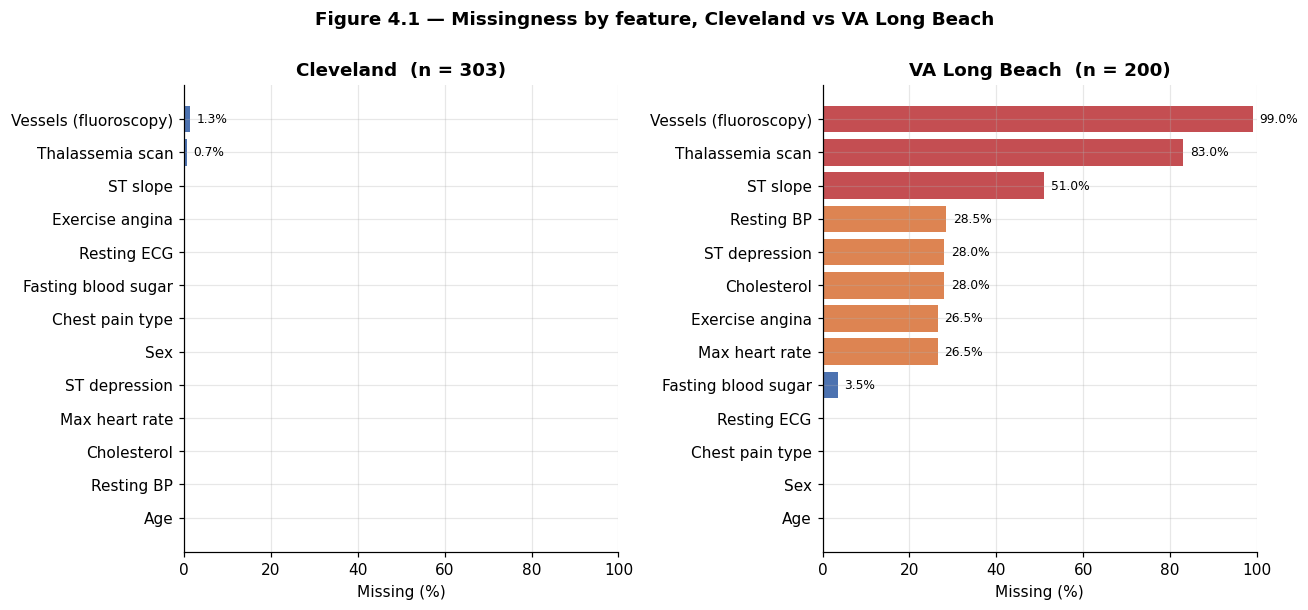

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True)
for ax, (label, df) in zip(axes, DATASETS.items()):
    pct = (df[FEATURES].isna().mean() * 100).sort_values()
    colours = ["#c44e52" if v > 50 else "#dd8452" if v > 10 else "#4c72b0" for v in pct]
    ax.barh([PRETTY[i] for i in pct.index], pct.values, color=colours)
    ax.set_title(f"{label}  (n = {len(df)})", fontweight="bold")
    ax.set_xlabel("Missing (%)")
    ax.set_xlim(0, 100)
    for y, v in enumerate(pct.values):
        if v > 0:
            ax.text(v + 1.5, y, f"{v:.1f}%", va="center", fontsize=8)

fig.suptitle("Figure 4.1 — Missingness by feature, Cleveland vs VA Long Beach",
             fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_4_1_missingness_by_column.png")
plt.show()

## 1.4 — Figure 4.2: the *pattern* of missingness in VA

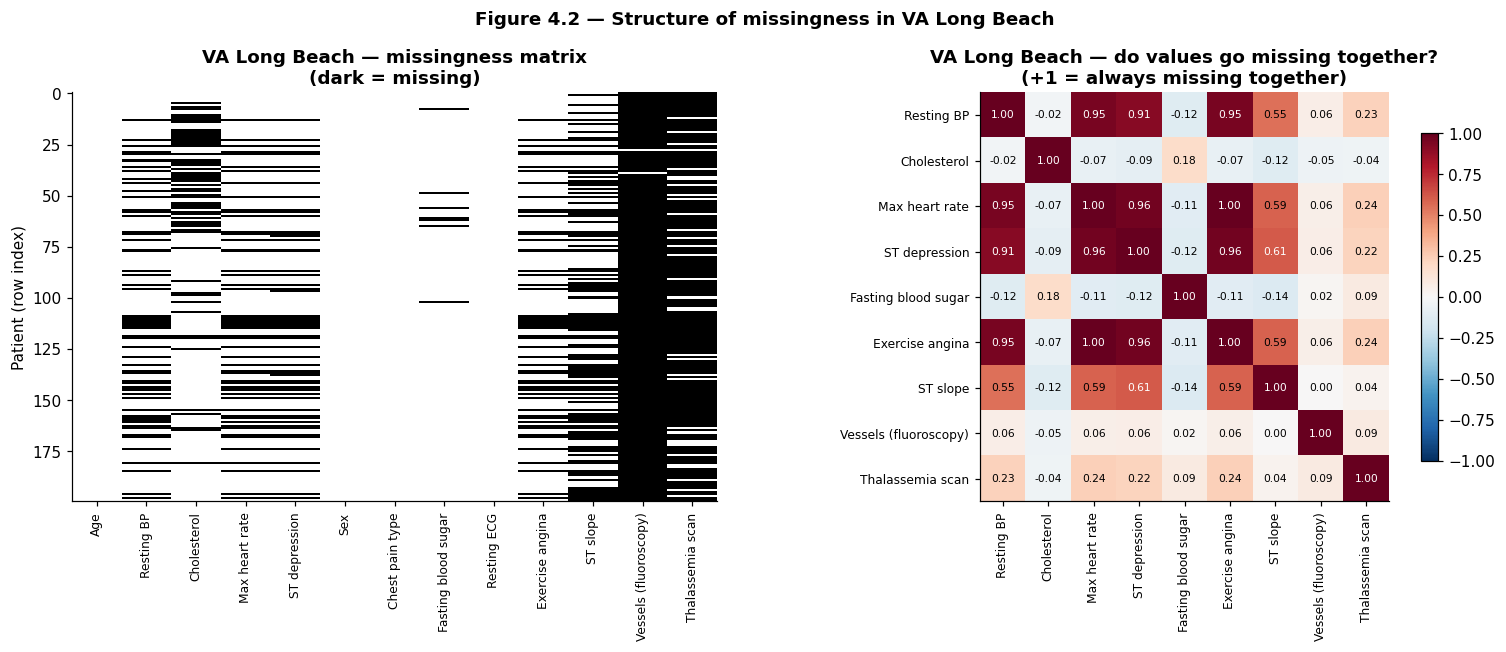

In [6]:
cols_with_missing = [c for c in FEATURES if va[c].isna().any()]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(va[FEATURES].isna().astype(int).values, aspect="auto",
               cmap="Greys", interpolation="nearest")
axes[0].set_xticks(range(len(FEATURES)))
axes[0].set_xticklabels([PRETTY[f] for f in FEATURES], rotation=90, fontsize=8)
axes[0].set_ylabel("Patient (row index)")
axes[0].set_title("VA Long Beach — missingness matrix\n(dark = missing)", fontweight="bold")
axes[0].grid(False)

corr_miss = va[cols_with_missing].isna().astype(int).corr()
im = axes[1].imshow(corr_miss, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(cols_with_missing)))
axes[1].set_xticklabels([PRETTY[c] for c in cols_with_missing], rotation=90, fontsize=8)
axes[1].set_yticks(range(len(cols_with_missing)))
axes[1].set_yticklabels([PRETTY[c] for c in cols_with_missing], fontsize=8)
axes[1].set_title("VA Long Beach — do values go missing together?\n(+1 = always missing together)",
                  fontweight="bold")
axes[1].grid(False)
for i in range(len(corr_miss)):
    for j in range(len(corr_miss)):
        v = corr_miss.iloc[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                         color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=axes[1], shrink=0.8)

fig.suptitle("Figure 4.2 — Structure of missingness in VA Long Beach", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_4_2_missingness_pattern_va.png")
plt.show()

## 1.5 — Is the missingness MCAR?  *(Table 4.2)*

In [7]:
FULLY_OBSERVED = ["age", "sex", TARGET]

rows = []
for col in cols_with_missing:
    is_missing = va[col].isna()
    if min(int(is_missing.sum()), int((~is_missing).sum())) < 10:
        continue                                     # too few in one group to test
    for probe in FULLY_OBSERVED:
        grp_miss = va.loc[is_missing, probe].dropna()
        grp_obs  = va.loc[~is_missing, probe].dropna()
        if probe == "age":                           # continuous -> Welch t-test
            stat, p = stats.ttest_ind(grp_miss, grp_obs, equal_var=False)
            summary, test = f"mean {grp_miss.mean():.1f} vs {grp_obs.mean():.1f}", "Welch t-test"
        else:                                        # binary -> chi-square
            stat, p, _, _ = stats.chi2_contingency(pd.crosstab(is_missing, va[probe]))
            summary, test = f"{grp_miss.mean()*100:.0f}% vs {grp_obs.mean()*100:.0f}%", "Chi-square"
        rows.append({
            "Feature missing": PRETTY[col],
            "% missing": round(is_missing.mean() * 100, 1),
            "Compared on": PRETTY[probe],
            "Missing vs observed": summary,
            "Test": test,
            "p-value": round(p, 4),
            "Not MCAR?": "YES" if p < 0.05 else "no",
        })

mech_tests = pd.DataFrame(rows)
mech_tests.to_csv(OUT_TABLES / "table_4_2_missingness_mechanism_tests.csv", index=False)
print(f"{int((mech_tests['p-value'] < 0.05).sum())} of {len(mech_tests)} comparisons significant (p < 0.05).")
mech_tests

2 of 21 comparisons significant (p < 0.05).


,Feature missing,% missing,Compared on,Missing vs observed,Test,p-value,Not MCAR?
0,Resting BP,28.5,Age,mean 59.4 vs 59.3,Welch t-test,0.9178,no
1,Resting BP,28.5,Sex,98% vs 97%,Chi-square,0.8471,no
2,Resting BP,28.5,Heart disease,67% vs 78%,Chi-square,0.1542,no
3,Cholesterol,28.0,Age,mean 58.9 vs 59.5,Welch t-test,0.6143,no
4,Cholesterol,28.0,Sex,98% vs 97%,Chi-square,0.8680,no
5,Cholesterol,28.0,Heart disease,77% vs 74%,Chi-square,0.7781,no
6,Max heart rate,26.5,Age,mean 59.5 vs 59.3,Welch t-test,0.9110,no
7,Max heart rate,26.5,Sex,98% vs 97%,Chi-square,0.9326,no
8,Max heart rate,26.5,Heart disease,64% vs 78%,Chi-square,0.0669,no
9,ST depression,28.0,Age,mean 59.3 vs 59.4,Welch t-test,0.9577,no


## 1.6 — Figures 4.3 and 4.4: Cleveland distributions and correlation structure

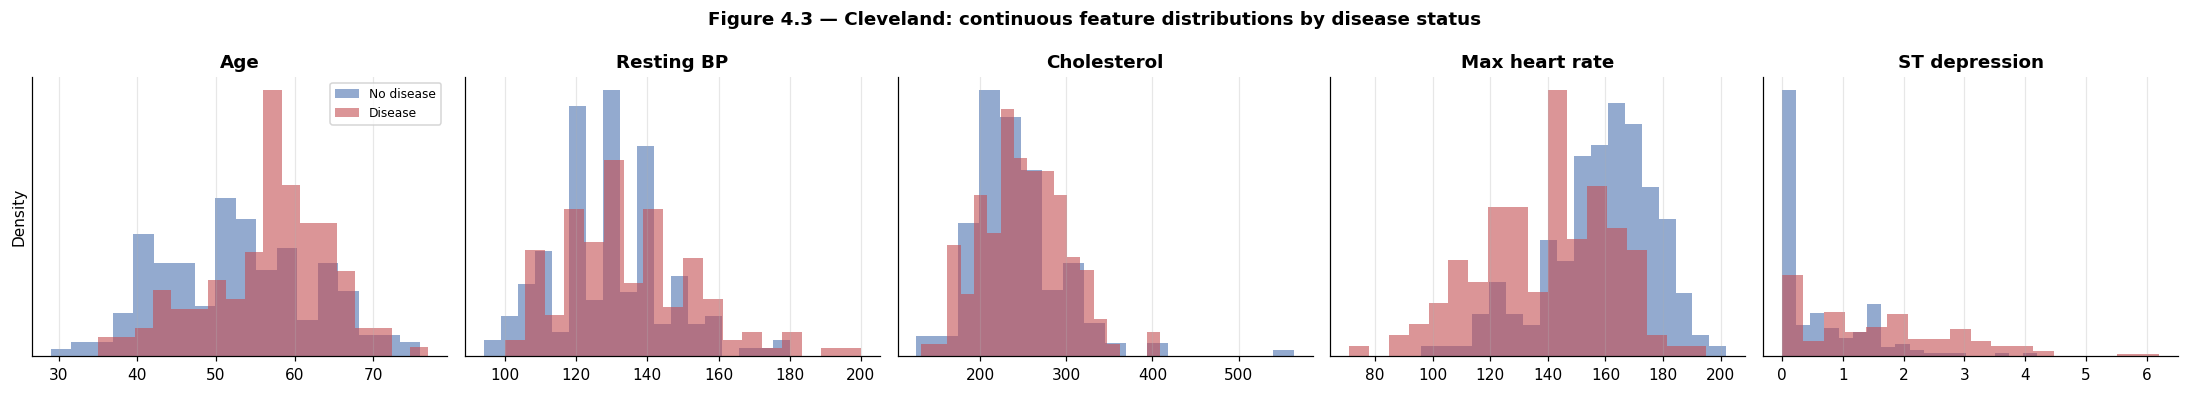

Skewness (|skew| > 1 = strongly skewed, mean imputation will distort it):
  Age               -0.21
  Resting BP         0.71
  Cholesterol        1.14
  Max heart rate    -0.54
  ST depression      1.27


In [8]:
fig, axes = plt.subplots(1, len(CONTINUOUS), figsize=(4 * len(CONTINUOUS), 3.6))
for ax, col in zip(axes, CONTINUOUS):
    for cls, colour, name in [(0, "#4c72b0", "No disease"), (1, "#c44e52", "Disease")]:
        ax.hist(cleveland.loc[cleveland[TARGET] == cls, col].dropna(),
                bins=18, alpha=0.6, color=colour, label=name, density=True)
    ax.set_title(PRETTY[col], fontweight="bold")
    ax.set_yticks([])
axes[0].legend(fontsize=8)
axes[0].set_ylabel("Density")
fig.suptitle("Figure 4.3 — Cleveland: continuous feature distributions by disease status",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_4_3_cleveland_distributions.png")
plt.show()

print("Skewness (|skew| > 1 = strongly skewed, mean imputation will distort it):")
for col in CONTINUOUS:
    print(f"  {PRETTY[col]:<16} {cleveland[col].dropna().skew():>6.2f}")

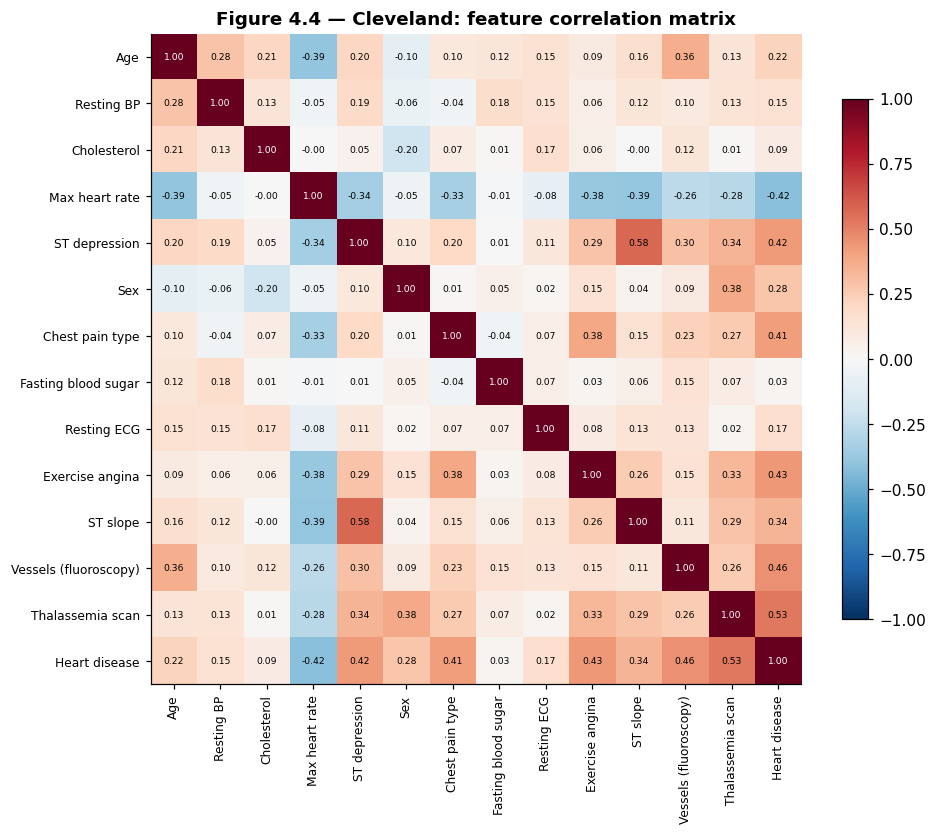

In [9]:
corr = cleveland[FEATURES + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
labels = [PRETTY[c] for c in corr.columns]
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=8)
ax.grid(False)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(corr.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Figure 4.4 — Cleveland: feature correlation matrix", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_4_4_cleveland_correlation.png")
plt.show()

## 1.7 — Baseline characteristics *(Table 4.1c)*

In [10]:
cont_rows = []
for label, df in DATASETS.items():
    for col in CONTINUOUS:
        s = df[col].dropna()
        cont_rows.append({"Feature": PRETTY[col], "Dataset": label,
                           "cell": f"{s.mean():.1f} ({s.std():.1f})"})
cont_table = (pd.DataFrame(cont_rows)
                .pivot(index="Feature", columns="Dataset", values="cell")
                .reindex(index=[PRETTY[c] for c in CONTINUOUS]))

cat_rows = []
for label, df in DATASETS.items():
    n_total = len(df)
    for col in CATEGORICAL + [TARGET]:
        for level, count in df[col].dropna().value_counts().sort_index().items():
            cat_rows.append({"Feature": PRETTY.get(col, col), "Level": level, "Dataset": label,
                              "cell": f"{int(count)} ({count / n_total * 100:.1f}%)"})
cat_table = (pd.DataFrame(cat_rows)
               .pivot_table(index=["Feature", "Level"], columns="Dataset", values="cell", aggfunc="first"))

n_row = pd.DataFrame({label: [f"{len(df)}"] for label, df in DATASETS.items()},
                      index=pd.MultiIndex.from_tuples([("N", "")]))
n_row.index.names = cat_table.index.names
disease_row = pd.DataFrame(
    {label: [f"{df[TARGET].sum()} ({df[TARGET].mean()*100:.1f}%)"] for label, df in DATASETS.items()},
    index=pd.MultiIndex.from_tuples([("Disease rate", "")]))
disease_row.index.names = cat_table.index.names

cont_table.to_csv(OUT_TABLES / "table_4_1c_baseline_continuous.csv")
cat_table.to_csv(OUT_TABLES / "table_4_1c_baseline_categorical.csv")

print("Table 4.1c — Baseline characteristics, continuous features: mean (SD), non-missing values only")
print(cont_table.to_string())
print("\nTable 4.1c — Baseline characteristics, categorical features: n (%) of dataset total")
print(pd.concat([n_row, disease_row, cat_table]).to_string())


Table 4.1c — Baseline characteristics, continuous features: mean (SD), non-missing values only
Dataset            Cleveland VA Long Beach
Feature                                   
Age               54.4 (9.0)    59.4 (7.8)
Resting BP      131.7 (17.6)  134.7 (18.4)
Cholesterol     246.7 (51.8)  239.6 (52.8)
Max heart rate  149.6 (22.9)  122.8 (22.0)
ST depression      1.0 (1.2)     1.3 (1.1)

Table 4.1c — Baseline characteristics, categorical features: n (%) of dataset total
                               Cleveland VA Long Beach
Feature               Level                           
N                                    303           200
Disease rate                 139 (45.9%)   149 (74.5%)
Chest pain type       1.0      23 (7.6%)      8 (4.0%)
                      2.0     50 (16.5%)     14 (7.0%)
                      3.0     86 (28.4%)    47 (23.5%)
                      4.0    144 (47.5%)   131 (65.5%)
Exercise angina       0.0    204 (67.3%)    52 (26.0%)
                      1.

---
# STEP 2 — Controlled missingness injection  *(Objective O2, §3.3)*

## 2.1 — Complete-case ground truth, and the experimental grid

In [11]:
GROUND_TRUTH = (pd.read_csv(DATA_CLEAN / "cleveland_clean.csv")
                  .dropna(subset=FEATURES + [TARGET])
                  .reset_index(drop=True))
assert GROUND_TRUTH[FEATURES + [TARGET]].isna().sum().sum() == 0
GROUND_TRUTH.to_csv(DATA_CLEAN / "cleveland_ground_truth.csv", index=False)

# age and sex are held fully observed: both are 100% present in Cleveland AND VA, and MAR
# requires an observed variable to condition on. The target is never amputated.
ALWAYS_OBSERVED    = ["age", "sex"]
AMPUTE_COLS        = [f for f in FEATURES if f not in ALWAYS_OBSERVED]     # order matters (RNG)
AMPUTE_CONTINUOUS  = [f for f in AMPUTE_COLS if f in CONTINUOUS]

MECHANISMS = ["MCAR", "MAR", "MNAR"]
RATES      = [0.10, 0.20, 0.30]
# 8 repeats: the minimum n at which a Bonferroni-corrected (x6 pairs) two-sided Wilcoxon
# signed-rank test can reach p < .05 at all -- at n=5 the exact-test floor is p=.0625,
# which is already > .05/6 before any real data is considered, so no pairwise post-hoc
# comparison could ever have been significant at the old repeat count.
N_REPEATS  = 8
SEEDS      = [RANDOM_STATE + i for i in range(N_REPEATS)]      # 42, 43, ..., 49
N_VARIANTS = len(MECHANISMS) * len(RATES) * N_REPEATS          # 72

BIAS_STRENGTH  = 2.0        # how strongly MAR/MNAR skew which cells go missing
MAR_DEPENDS_ON = "age"      # the observed variable that drives MAR missingness

print(f"Ground truth: {len(GROUND_TRUTH)} patients, 0 missing cells")
print(f"Amputated columns ({len(AMPUTE_COLS)}): {AMPUTE_COLS}")
print(f"Grid: {len(MECHANISMS)} mechanisms x {len(RATES)} rates x {N_REPEATS} seeds = {N_VARIANTS} variants")

Ground truth: 297 patients, 0 missing cells
Amputated columns (11): ['trestbps', 'chol', 'thalach', 'oldpeak', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Grid: 3 mechanisms x 3 rates x 8 seeds = 72 variants


## 2.2 — The amputation function

In [12]:
def _selection_weights(values: np.ndarray, k: float) -> np.ndarray:
    """Exponential-tilt weights from the ranks of `values`. Higher value -> higher weight."""
    ranks = stats.rankdata(values)
    z = (ranks - ranks.mean()) / ranks.std()
    w = np.exp(k * z)
    return w / w.sum()


def amputate(df: pd.DataFrame, mechanism: str, rate: float, seed: int,
             cols: list = None, k: float = None) -> pd.DataFrame:
    """Delete `rate` of the values in each target column under the given mechanism."""
    cols = AMPUTE_COLS if cols is None else cols
    k = BIAS_STRENGTH if k is None else k

    rng = np.random.default_rng(seed)
    out = df.copy()                          # ground truth is never modified
    n = len(out)
    n_missing = int(round(rate * n))

    for col in cols:
        if mechanism == "MCAR":              # pure lottery
            idx = rng.choice(n, size=n_missing, replace=False)
        elif mechanism == "MAR":             # driven by an OBSERVED variable (age)
            w = _selection_weights(df[MAR_DEPENDS_ON].to_numpy(), k)
            idx = rng.choice(n, size=n_missing, replace=False, p=w)
        elif mechanism == "MNAR":            # driven by the deleted value itself
            w = _selection_weights(df[col].to_numpy(), k)
            idx = rng.choice(n, size=n_missing, replace=False, p=w)
        else:
            raise ValueError(f"mechanism must be one of {MECHANISMS}, got {mechanism!r}")
        out.iloc[idx, out.columns.get_loc(col)] = np.nan

    return out

## 2.3 — Manipulation check  *(Table 3.2)*

In [13]:
ALPHA = 0.05
zscore = lambda s: (s - s.mean()) / s.std()

rows = []
for mech in MECHANISMS:
    v = amputate(GROUND_TRUTH, mech, rate=0.30, seed=RANDOM_STATE)
    for col in AMPUTE_CONTINUOUS:
        y = v[col].isna().astype(int)                       # 1 = value was deleted
        X = sm.add_constant(pd.DataFrame({
            "age":        zscore(GROUND_TRUTH["age"]),
            "true_value": zscore(GROUND_TRUTH[col]),        # the value BEFORE deletion
        }))
        fit = sm.Logit(y, X).fit(disp=0)
        p_age, p_val = fit.pvalues["age"], fit.pvalues["true_value"]
        rows.append({
            "Mechanism": mech, "Feature": PRETTY[col],
            "coef age": round(fit.params["age"], 3), "p age": round(p_age, 4),
            "age drives it?": "YES" if p_age < ALPHA else "no",
            "coef value|age": round(fit.params["true_value"], 3), "p value|age": round(p_val, 4),
            "value drives it?": "YES" if p_val < ALPHA else "no",
        })

mechanism_check = pd.DataFrame(rows)
mechanism_check.to_csv(OUT_TABLES / "table_3_2_mechanism_validation.csv", index=False)

expected = {"MCAR": ("no", "no"), "MAR": ("YES", "no"), "MNAR": ("no", "YES")}
for mech in MECHANISMS:
    sub = mechanism_check[mechanism_check["Mechanism"] == mech]
    got = ("YES" if (sub["age drives it?"] == "YES").mean() > 0.5 else "no",
           "YES" if (sub["value drives it?"] == "YES").mean() > 0.5 else "no")
    print(f"  {mech:<5} age={got[0]:<3} value|age={got[1]:<3} "
          f"(expected {expected[mech][0]}/{expected[mech][1]})  "
          f"{'PASS' if got == expected[mech] else '*** FAIL ***'}")

mechanism_check

  MCAR  age=no  value|age=no  (expected no/no)  PASS
  MAR   age=YES value|age=no  (expected YES/no)  PASS
  MNAR  age=no  value|age=YES (expected no/YES)  PASS


,Mechanism,Feature,coef age,p age,age drives it?,coef value|age,p value|age,value drives it?
0,MCAR,Resting BP,0.113,0.3985,no,-0.026,0.8460,no
1,MCAR,Cholesterol,-0.032,0.8062,no,-0.084,0.5254,no
2,MCAR,Max heart rate,-0.014,0.9208,no,-0.043,0.7562,no
3,MCAR,ST depression,0.101,0.4378,no,0.058,0.6520,no
4,MAR,Resting BP,3.254,0.0000,YES,0.024,0.8931,no
5,MAR,Cholesterol,2.890,0.0000,YES,-0.041,0.8095,no
6,MAR,Max heart rate,3.081,0.0000,YES,0.160,0.4012,no
7,MAR,ST depression,2.769,0.0000,YES,0.074,0.6475,no
8,MNAR,Resting BP,-0.299,0.1138,no,2.603,0.0000,YES
9,MNAR,Cholesterol,0.097,0.6353,no,3.228,0.0000,YES


## 2.4 — Figure 3.1: what each mechanism deletes

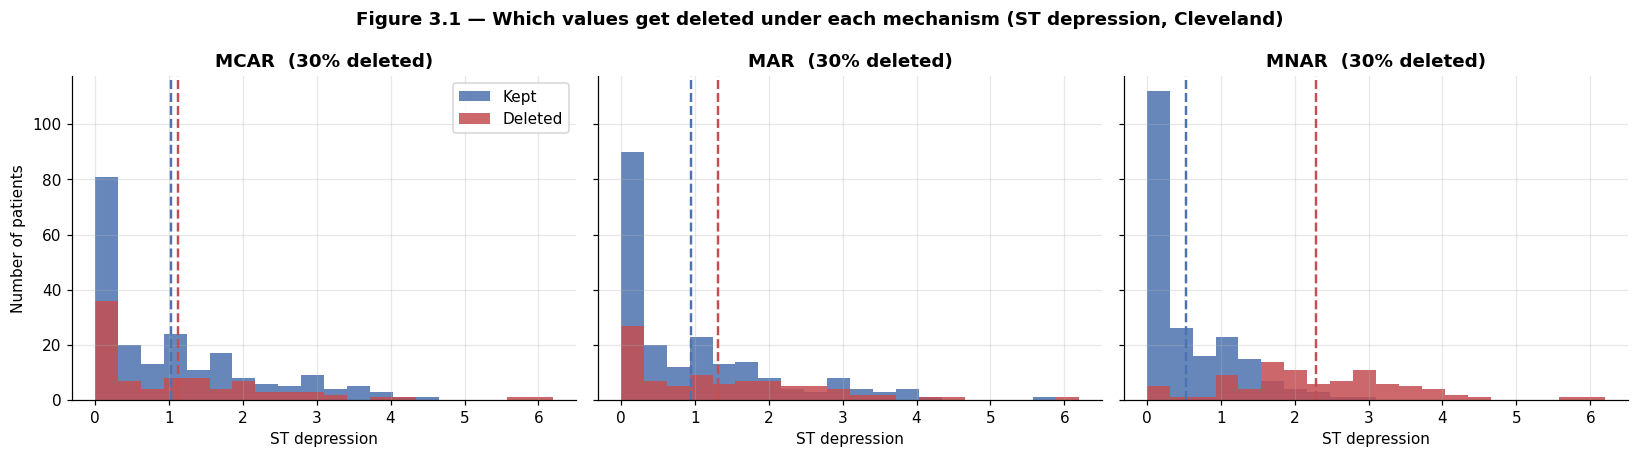

In [14]:
PROBE_COL = "oldpeak"

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, mech in zip(axes, MECHANISMS):
    v = amputate(GROUND_TRUTH, mech, rate=0.30, seed=RANDOM_STATE)
    deleted = v[PROBE_COL].isna()
    bins = np.histogram_bin_edges(GROUND_TRUTH[PROBE_COL], bins=20)
    ax.hist(GROUND_TRUTH.loc[~deleted, PROBE_COL], bins=bins, color="#4c72b0", alpha=0.85, label="Kept")
    ax.hist(GROUND_TRUTH.loc[deleted, PROBE_COL],  bins=bins, color="#c44e52", alpha=0.85, label="Deleted")
    ax.axvline(GROUND_TRUTH.loc[deleted, PROBE_COL].mean(),  color="#c44e52", ls="--", lw=1.6)
    ax.axvline(GROUND_TRUTH.loc[~deleted, PROBE_COL].mean(), color="#4c72b0", ls="--", lw=1.6)
    ax.set_title(f"{mech}  (30% deleted)", fontweight="bold")
    ax.set_xlabel(PRETTY[PROBE_COL])
axes[0].set_ylabel("Number of patients")
axes[0].legend()

fig.suptitle(f"Figure 3.1 — Which values get deleted under each mechanism "
             f"({PRETTY[PROBE_COL]}, Cleveland)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_3_1_mechanism_illustration.png")
plt.show()

## 2.5 — Generate the 72 variants and log the realised rates  *(Table 3.3)*

In [15]:
VARIANTS = {}
for mech in MECHANISMS:
    for rate in RATES:
        for seed in SEEDS:
            v = amputate(GROUND_TRUTH, mech, rate, seed)
            VARIANTS[(mech, rate, seed)] = v
            v.to_csv(DATA_VARIANTS / f"{mech}_rate{int(rate*100)}_seed{seed}.csv", index=False)
assert len(VARIANTS) == N_VARIANTS

variant_log = pd.DataFrame([{
    "Mechanism": mech, "Target rate": f"{rate:.0%}", "Seed": seed,
    "Realised (amputated cols)": v[AMPUTE_COLS].isna().mean().mean(),
    "Realised (all features)":   v[FEATURES].isna().mean().mean(),
    "Rows fully complete":       int((~v[FEATURES].isna().any(axis=1)).sum()),
} for (mech, rate, seed), v in VARIANTS.items()])

variant_summary = (variant_log
    .groupby(["Mechanism", "Target rate"], sort=False)
    .agg(**{"Realised % (amputated cols)": ("Realised (amputated cols)", lambda s: round(s.mean()*100, 2)),
            "Realised % (all features)":   ("Realised (all features)",   lambda s: round(s.mean()*100, 2)),
            "Mean complete rows":          ("Rows fully complete",       lambda s: round(s.mean(), 1))})
    .reset_index())

variant_log.to_csv(OUT_TABLES / "table_3_3_variant_log.csv", index=False)
variant_summary.to_csv(OUT_TABLES / "table_3_3_variant_summary.csv", index=False)

# The realised rate must equal the target, or "mechanism" would be confounded with "rate"
for _, r in variant_summary.iterrows():
    assert abs(r["Realised % (amputated cols)"] - float(r["Target rate"].strip("%"))) < 0.6

variant_summary

,Mechanism,Target rate,Realised % (amputated cols),Realised % (all features),Mean complete rows
0,MCAR,10%,10.10,8.55,93.2
1,MCAR,20%,19.87,16.81,27.0
2,MCAR,30%,29.97,25.36,6.4
3,MAR,10%,10.10,8.55,177.6
4,MAR,20%,19.87,16.81,138.9
5,MAR,30%,29.97,25.36,109.0
6,MNAR,10%,10.10,8.55,100.2
7,MNAR,20%,19.87,16.81,34.6
8,MNAR,30%,29.97,25.36,11.2


---
# STEP 3 — Imputation and reconstruction accuracy  *(RQ1, Results §4.2)*

## 3.1 — Imputer definitions and the two accuracy metrics

In [16]:
DOMAINS = {c: np.sort(GROUND_TRUTH[c].unique()) for c in FEATURES}


def snap_categoricals(df: pd.DataFrame, domains: dict, cat_cols=None) -> pd.DataFrame:
    """Round model-based imputations back onto the nearest legal category value."""
    out = df.copy()
    for col in (CATEGORICAL if cat_cols is None else cat_cols):
        dom = domains[col]
        vals = out[col].to_numpy()[:, None]
        out[col] = dom[np.abs(vals - dom[None, :]).argmin(axis=1)]
    return out


def make_imputers(random_state: int) -> dict:
    def mean_mode(df):
        out = df.copy()
        out[CONTINUOUS]  = SimpleImputer(strategy="mean").fit_transform(df[CONTINUOUS])
        out[CATEGORICAL] = SimpleImputer(strategy="most_frequent").fit_transform(df[CATEGORICAL])
        return out

    def knn(df):
        scaler = StandardScaler()
        scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
        arr = KNNImputer(n_neighbors=5).fit_transform(scaled)
        unscaled = pd.DataFrame(scaler.inverse_transform(arr), columns=df.columns, index=df.index)
        return snap_categoricals(unscaled, DOMAINS)

    def mice(df):
        imp = IterativeImputer(estimator=BayesianRidge(), max_iter=10,
                               random_state=random_state, sample_posterior=False)
        arr = imp.fit_transform(df)
        return snap_categoricals(pd.DataFrame(arr, columns=df.columns, index=df.index), DOMAINS)

    def rf_iterative(df):
        rf = RandomForestRegressor(n_estimators=100, max_depth=None, n_jobs=-1,
                                   random_state=random_state)
        imp = IterativeImputer(estimator=rf, max_iter=5, random_state=random_state)
        arr = imp.fit_transform(df)
        return snap_categoricals(pd.DataFrame(arr, columns=df.columns, index=df.index), DOMAINS)

    return {"KNN": knn, "Mean/Mode": mean_mode, "MICE": mice, "RF-iterative": rf_iterative}


FOLDER_TO_LABEL = {"knn": "KNN", "mean_mode": "Mean/Mode",
                   "mice": "MICE", "rf_iterative": "RF-iterative"}
LABEL_TO_FOLDER = {v: k for k, v in FOLDER_TO_LABEL.items()}
METHOD_ORDER    = ["KNN", "Mean/Mode", "MICE", "RF-iterative"]


def nrmse_continuous(truth, imputed, mask_isna) -> float:
    """RMSE over the imputed continuous cells only, each standardised by the true column SD."""
    errs = []
    for c in CONTINUOUS:
        m = mask_isna[c].to_numpy()
        sd = truth[c].std()
        if m.sum() == 0 or sd == 0:
            continue
        errs.append(((imputed[c].to_numpy()[m] - truth[c].to_numpy()[m]) / sd) ** 2)
    return float(np.sqrt(np.concatenate(errs).mean())) if errs else np.nan


def pfc_categorical(truth, imputed, mask_isna) -> float:
    """Proportion of imputed categorical cells given the wrong category."""
    wrong = total = 0
    for c in CATEGORICAL:
        m = mask_isna[c].to_numpy()
        if m.sum() == 0:
            continue
        wrong += int((np.round(imputed[c].to_numpy()[m]) != np.round(truth[c].to_numpy()[m])).sum())
        total += int(m.sum())
    return float(wrong / total) if total else np.nan

## 3.2 — Impute all 288 variant × method combinations and score them

In [17]:
if not REUSE_EXISTING_IMPUTATIONS:
    t0 = time.perf_counter()
    for label in METHOD_ORDER:
        (DATA_IMPUTED / LABEL_TO_FOLDER[label]).mkdir(parents=True, exist_ok=True)
    for (mech, rate, seed), v in VARIANTS.items():
        fn = f"{mech}_rate{int(rate*100)}_seed{seed}.csv"
        imputers = make_imputers(random_state=seed)         # imputer seed = variant seed
        for label, fn_impute in imputers.items():
            fn_impute(v[FEATURES].copy()).to_csv(
                DATA_IMPUTED / LABEL_TO_FOLDER[label] / fn, index=False)
    print(f"Imputed {N_VARIANTS} variants x 4 methods in {time.perf_counter() - t0:.1f}s "
          f"-> {DATA_IMPUTED.relative_to(PROJECT_ROOT)}/")

# Score every imputed dataset against the ground truth, on the imputed cells only
score_rows = []
for (mech, rate, seed), v in VARIANTS.items():
    fn = f"{mech}_rate{int(rate*100)}_seed{seed}.csv"
    mask_isna = v[FEATURES].isna()
    for label in METHOD_ORDER:
        imp = pd.read_csv(DATA_IMPUTED / LABEL_TO_FOLDER[label] / fn)
        score_rows.append({
            "method": label, "mechanism": mech, "rate": rate, "seed": seed,
            "nrmse": nrmse_continuous(GROUND_TRUTH[FEATURES], imp, mask_isna),
            "pfc":   pfc_categorical(GROUND_TRUTH[FEATURES], imp, mask_isna),
            "variant_filename": fn,
            "n_missing_cells_scored":     int(mask_isna.sum().sum()),
            "n_continuous_cells_scored":  int(mask_isna[CONTINUOUS].sum().sum()),
            "n_categorical_cells_scored": int(mask_isna[CATEGORICAL].sum().sum()),
        })

rq1_scores = (pd.DataFrame(score_rows)
                .sort_values(["method", "mechanism", "rate", "seed"])
                .reset_index(drop=True))
assert len(rq1_scores) == N_VARIANTS * len(METHOD_ORDER)
rq1_scores.to_csv(OUT_TABLES / "table_rq1_seed_level_scores.csv", index=False)
print(f"{len(rq1_scores)} seed-level RQ1 scores (4 methods x 9 conditions x {N_REPEATS} seeds).")
rq1_scores.head()

288 seed-level RQ1 scores (4 methods x 9 conditions x 8 seeds).


,method,mechanism,rate,seed,nrmse,pfc,variant_filename,n_missing_cells_scored,n_continuous_cells_scored,n_categorical_cells_scored
0,KNN,MAR,0.1,42,1.152217,0.509524,MAR_rate10_seed42.csv,330,120,210
1,KNN,MAR,0.1,43,1.061645,0.547619,MAR_rate10_seed43.csv,330,120,210
2,KNN,MAR,0.1,44,0.967277,0.485714,MAR_rate10_seed44.csv,330,120,210
3,KNN,MAR,0.1,45,1.020872,0.552381,MAR_rate10_seed45.csv,330,120,210
4,KNN,MAR,0.1,46,1.070892,0.514286,MAR_rate10_seed46.csv,330,120,210


## 3.3 — RQ1 descriptive results  *(Tables 4.2a and 4.2b)*

In [18]:
rq1_summary = (rq1_scores
    .groupby(["method", "mechanism", "rate"], as_index=False)
    .agg(n=("nrmse", "size"),
         nrmse_mean=("nrmse", "mean"), nrmse_sd=("nrmse", "std"),
         pfc_mean=("pfc", "mean"),     pfc_sd=("pfc", "std")))
rq1_summary.to_csv(OUT_TABLES / "table_rq1_descriptive_summary.csv", index=False)

CONDITION_ORDER = [f"{m}-{int(r*100)}%" for m in ["MCAR", "MAR", "MNAR"] for r in RATES]


def condition_matrix(summary: pd.DataFrame, mean_col: str, sd_col: str) -> pd.DataFrame:
    """mean ± sd per method x (mechanism, rate), formatted for the dissertation tables."""
    df = summary.copy()
    df["condition"] = df["mechanism"] + "-" + (df["rate"] * 100).astype(int).astype(str) + "%"
    df["cell"] = df[mean_col].map("{:.3f}".format) + " ± " + df[sd_col].map("{:.3f}".format)
    return (df.pivot(index="method", columns="condition", values="cell")
              .reindex(index=METHOD_ORDER, columns=CONDITION_ORDER)
              .rename_axis(None, axis=1).reset_index())


nrmse_matrix = condition_matrix(rq1_summary, "nrmse_mean", "nrmse_sd")
pfc_matrix   = condition_matrix(rq1_summary, "pfc_mean", "pfc_sd")
nrmse_matrix.to_csv(OUT_TABLES / "table_4_2a_nrmse_matrix.csv", index=False)
pfc_matrix.to_csv(OUT_TABLES / "table_4_2b_pfc_matrix.csv", index=False)

print(f"NRMSE (lower is better) — mean ± sd over {N_REPEATS} seeds")
print(nrmse_matrix.to_string(index=False))
print(f"\nPFC (lower is better) — mean ± sd over {N_REPEATS} seeds")
print(pfc_matrix.to_string(index=False))

NRMSE (lower is better) — mean ± sd over 8 seeds
      method      MCAR-10%      MCAR-20%      MCAR-30%       MAR-10%       MAR-20%       MAR-30%      MNAR-10%      MNAR-20%      MNAR-30%
         KNN 0.964 ± 0.083 0.962 ± 0.029 0.994 ± 0.039 1.050 ± 0.055 1.133 ± 0.037 1.099 ± 0.038 1.494 ± 0.062 1.548 ± 0.049 1.577 ± 0.033
   Mean/Mode 0.969 ± 0.067 0.989 ± 0.053 1.017 ± 0.044 1.059 ± 0.047 1.132 ± 0.039 1.093 ± 0.023 1.645 ± 0.073 1.692 ± 0.037 1.664 ± 0.011
        MICE 0.900 ± 0.067 0.904 ± 0.055 0.984 ± 0.064 0.973 ± 0.084 1.051 ± 0.037 1.025 ± 0.021 1.430 ± 0.072 1.535 ± 0.043 1.538 ± 0.025
RF-iterative 0.927 ± 0.098 0.946 ± 0.032 1.000 ± 0.049 1.041 ± 0.063 1.156 ± 0.049 1.133 ± 0.075 1.438 ± 0.078 1.504 ± 0.039 1.512 ± 0.031

PFC (lower is better) — mean ± sd over 8 seeds
      method      MCAR-10%      MCAR-20%      MCAR-30%       MAR-10%       MAR-20%       MAR-30%      MNAR-10%      MNAR-20%      MNAR-30%
         KNN 0.451 ± 0.044 0.464 ± 0.021 0.477 ± 0.018 0.510 ± 0.030 

## 3.4 — Figure 4.5: NRMSE by rate, mechanism and method

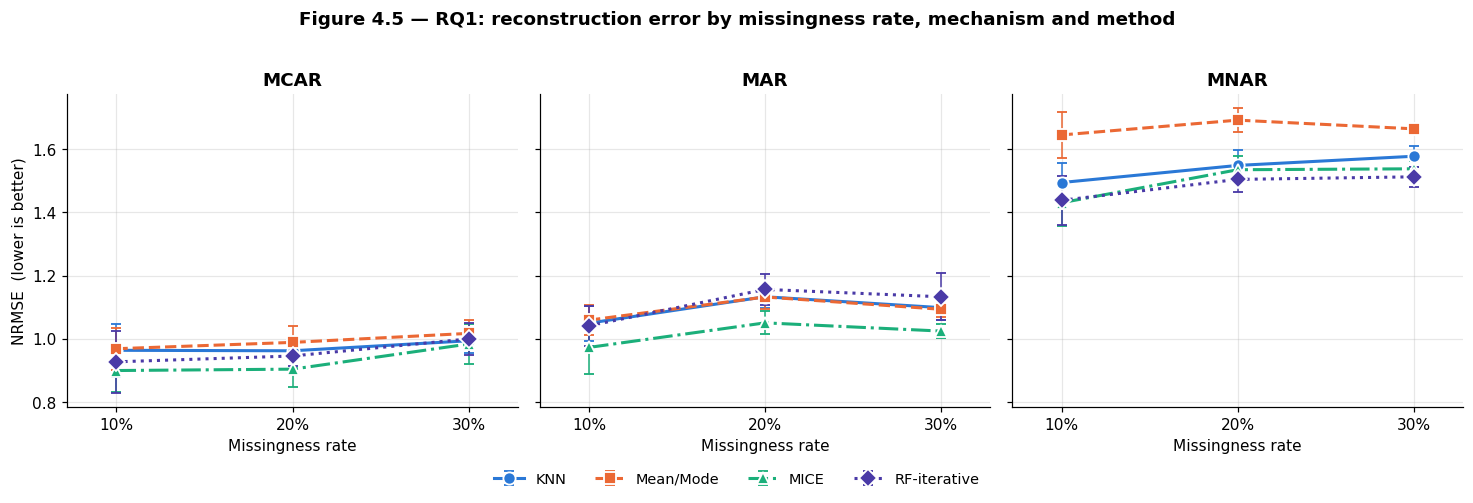

In [19]:
# Fixed method -> colour / marker / line-style, reused identically by both figures so the
# RQ1 and RQ2 charts can be read side by side. The colours are validated for colour-blind
# separation, and marker + line-style repeat the identity so no series relies on colour alone.
METHOD_COLOUR = {"KNN": "#2a78d6", "Mean/Mode": "#eb6834", "MICE": "#1baf7a", "RF-iterative": "#4a3aa7"}
METHOD_MARKER = {"KNN": "o", "Mean/Mode": "s", "MICE": "^", "RF-iterative": "D"}
METHOD_STYLE  = {"KNN": "-", "Mean/Mode": "--", "MICE": "-.", "RF-iterative": ":"}


def small_multiples_by_mechanism(summary, mean_col, sd_col, ylabel, title, filename):
    """One panel per mechanism, missingness rate on x, one line per method.

    Error bars are +/-1 SD across the N_REPEATS seeds. The three panels share a y-axis, which is
    what makes the mechanisms directly comparable at a glance.
    """
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4), sharey=True)

    for ax, mech in zip(axes, MECHANISMS):
        panel = summary[summary["mechanism"] == mech]
        for method in METHOD_ORDER:
            s = panel[panel["method"] == method].sort_values("rate")
            ax.errorbar(s["rate"] * 100, s[mean_col], yerr=s[sd_col], label=method,
                        color=METHOD_COLOUR[method], marker=METHOD_MARKER[method],
                        linestyle=METHOD_STYLE[method], linewidth=2, markersize=8,
                        markeredgecolor="white", markeredgewidth=1.2,
                        capsize=3, elinewidth=1)
        ax.set_title(mech, fontweight="bold")
        ax.set_xlabel("Missingness rate")
        ax.set_xticks([10, 20, 30])
        ax.set_xticklabels(["10%", "20%", "30%"])
        ax.margins(x=0.14)

    axes[0].set_ylabel(ylabel)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(METHOD_ORDER),
               frameon=False, fontsize=9.5, bbox_to_anchor=(0.5, -0.03))
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(OUT_FIGURES / filename)
    plt.show()


small_multiples_by_mechanism(
    rq1_summary, "nrmse_mean", "nrmse_sd",
    "NRMSE  (lower is better)",
    "Figure 4.5 — RQ1: reconstruction error by missingness rate, mechanism and method",
    "fig_4_5_rq1_nrmse_by_mechanism.png")

## 3.5 — Figure 4.5b: PFC by rate, mechanism and method

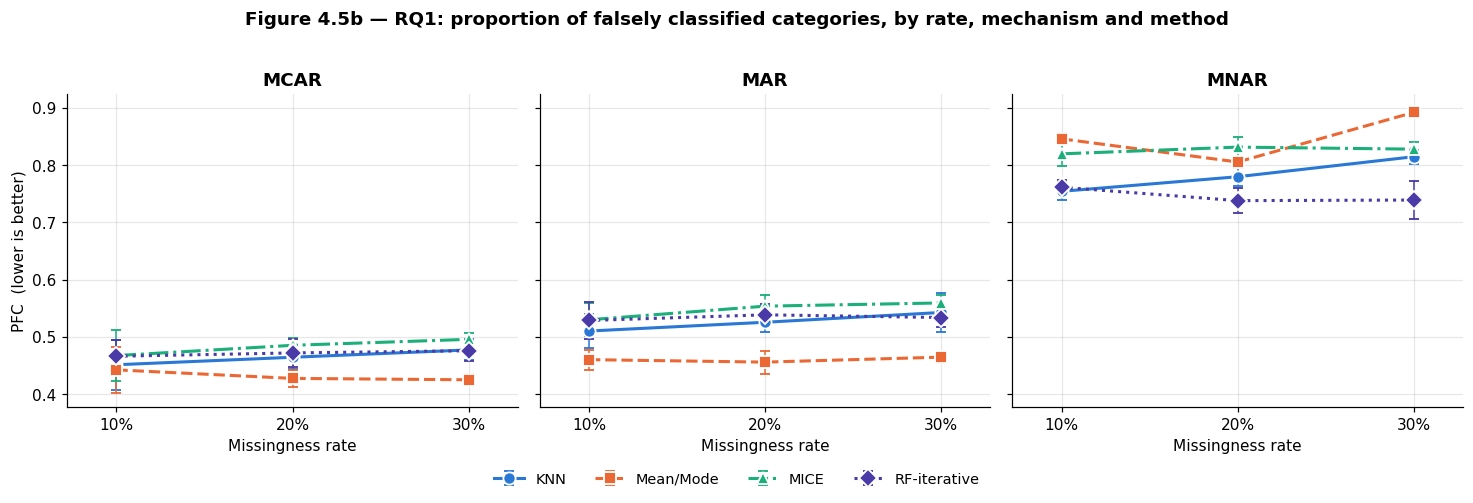

In [20]:
small_multiples_by_mechanism(
    rq1_summary, "pfc_mean", "pfc_sd",
    "PFC  (lower is better)",
    "Figure 4.5b — RQ1: proportion of falsely classified categories, by rate, mechanism and method",
    "fig_4_5b_rq1_pfc_by_mechanism.png")


---
# STEP 4 — RQ1 statistical evaluation  *(§6.1)*

In [21]:
METRICS_RQ1 = ["nrmse", "pfc"]
PAIRS = [("KNN", "Mean/Mode"), ("KNN", "MICE"), ("KNN", "RF-iterative"),
         ("Mean/Mode", "MICE"), ("Mean/Mode", "RF-iterative"), ("MICE", "RF-iterative")]


def friedman_table(scores: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """Friedman test per (mechanism, rate, metric); Kendall's W = chi2 / (n * (k - 1))."""
    rows = []
    for mech in MECHANISMS:
        for rate in RATES:
            for metric in metrics:
                sub = scores[(scores.mechanism == mech) & (scores.rate == rate)]
                pivot = sub.pivot(index="seed", columns="method", values=metric)[METHOD_ORDER]
                chi2, p = friedmanchisquare(*[pivot[m].to_numpy() for m in METHOD_ORDER])
                n, k = pivot.shape
                rows.append({"mechanism": mech, "rate": rate, "metric": metric,
                             "chi_square": chi2, "p": p, "kendalls_w": chi2 / (n * (k - 1))})
    return pd.DataFrame(rows)


def rank_biserial(diffs: np.ndarray):
    """Signed rank-sum rank-biserial correlation; convention method_a - method_b."""
    nz = diffs[diffs != 0]
    if len(nz) == 0:
        return np.nan, 0
    ranks = rankdata(np.abs(nz))
    w_pos, w_neg = ranks[nz > 0].sum(), ranks[nz < 0].sum()
    return (w_pos - w_neg) / (w_pos + w_neg), len(nz)


def wilcoxon_table(scores: pd.DataFrame, friedman: pd.DataFrame, metrics: list) -> pd.DataFrame:
    """Gated post-hoc: only families with a significant Friedman result are tested."""
    rows = []
    for mech in MECHANISMS:
        for rate in RATES:
            for metric in metrics:
                fr = friedman[(friedman.mechanism == mech) & (friedman.rate == rate)
                              & (friedman.metric == metric)]
                if fr.iloc[0]["p"] >= 0.05:
                    continue
                sub = scores[(scores.mechanism == mech) & (scores.rate == rate)]
                pivot = sub.pivot(index="seed", columns="method", values=metric)
                for a, b in PAIRS:
                    try:
                        stat, raw_p = wilcoxon(pivot[a], pivot[b], zero_method="wilcox")
                    except ValueError:
                        stat, raw_p = np.nan, 1.0
                    rb, n_eff = rank_biserial((pivot[a] - pivot[b]).to_numpy())
                    adj_p = min(raw_p * len(PAIRS), 1.0)          # Bonferroni within family
                    rows.append({"metric": metric, "mechanism": mech, "rate": rate,
                                 "method_a": a, "method_b": b, "statistic": stat,
                                 "raw_p": raw_p, "adjusted_p": adj_p, "rank_biserial": rb,
                                 "significance_indicator": "*" if adj_p < 0.05 else "",
                                 "n_effective": n_eff})
    return pd.DataFrame(rows)


rq1_friedman = friedman_table(rq1_scores, METRICS_RQ1)
rq1_wilcoxon = wilcoxon_table(rq1_scores, rq1_friedman, METRICS_RQ1)

rq1_friedman.to_csv(OUT_TABLES / "table_rq1_friedman_results.csv", index=False)
rq1_wilcoxon.to_csv(OUT_TABLES / "table_rq1_wilcoxon_posthoc.csv", index=False)

print(f"Friedman: {len(rq1_friedman)} families, {int((rq1_friedman.p < 0.05).sum())} significant at p<.05")
print(f"Wilcoxon: {len(rq1_wilcoxon)} pairwise tests, "
      f"{int((rq1_wilcoxon.adjusted_p < 0.05).sum())} significant after Bonferroni")
rq1_friedman

Friedman: 18 families, 16 significant at p<.05
Wilcoxon: 96 pairwise tests, 52 significant after Bonferroni


,mechanism,rate,metric,chi_square,p,kendalls_w
0,MCAR,0.1,nrmse,13.350000,0.003938,0.556250
1,MCAR,0.1,pfc,4.378378,0.223399,0.182432
2,MCAR,0.2,nrmse,16.650000,0.000834,0.693750
3,MCAR,0.2,pfc,16.800000,0.000777,0.700000
4,MCAR,0.3,nrmse,5.700000,0.127154,0.237500
5,MCAR,0.3,pfc,17.550000,0.000545,0.731250
6,MAR,0.1,nrmse,10.500000,0.014761,0.437500
7,MAR,0.1,pfc,13.441558,0.003773,0.560065
8,MAR,0.2,nrmse,13.500000,0.003671,0.562500
9,MAR,0.2,pfc,17.550000,0.000545,0.731250


---
# STEP 5 — RQ2 on Cleveland: explanation distortion vs. the true-data reference  *(§4.3)*

## 5.1 — Fixed 80/20 split, reference model, reference SHAP

In [22]:
gt = pd.read_csv(DATA_CLEAN / "cleveland_ground_truth.csv")

train_idx, test_idx = train_test_split(
    np.arange(len(gt)), test_size=0.2, random_state=SPLIT_SEED, stratify=gt[TARGET].to_numpy())

X_ref_train = gt.iloc[train_idx][FEATURES].to_numpy()
y_train     = gt.iloc[train_idx][TARGET].to_numpy()
X_test_eval = gt.iloc[test_idx][FEATURES].to_numpy()

ref_model = RandomForestClassifier(n_estimators=100, max_depth=None,
                                   random_state=SPLIT_SEED, n_jobs=-1)
ref_model.fit(X_ref_train, y_train)

print(f"Split: {len(train_idx)} train / {len(test_idx)} test, stratified, seed={SPLIT_SEED}")

Split: 237 train / 60 test, stratified, seed=42


## 5.2 — SHAP / LIME helpers

In [23]:
def global_shap_class1(model, X):
    """Mean |SHAP| per feature for the positive (disease) class."""
    sv = np.asarray(shap.TreeExplainer(model).shap_values(X, check_additivity=False))
    assert sv.ndim == 3 and sv.shape[2] == 2, f"unexpected SHAP shape {sv.shape}"
    return np.abs(sv[:, :, 1]).mean(axis=0)


def lime_weight_matrix(explainer, model, X, feature_names):
    """(patients x features) matrix of LIME weights for the positive class."""
    W = np.full((len(X), len(feature_names)), np.nan)
    for i in range(len(X)):
        exp = explainer.explain_instance(X[i], model.predict_proba,
                                         num_features=len(feature_names), num_samples=500)
        for fidx, w in exp.as_map()[1]:
            W[i, fidx] = w
    return W


def spearman_per_patient(ref_mat, imp_mat):
    """Row-by-row rank correlation; rows that cannot be validly correlated return NaN."""
    rhos = []
    for i in range(ref_mat.shape[0]):
        a, b = ref_mat[i], imp_mat[i]
        if np.any(np.isnan(a)) or np.any(np.isnan(b)) or np.all(a == a[0]) or np.all(b == b[0]):
            rhos.append(np.nan)
            continue
        rhos.append(spearmanr(a, b).correlation)
    return np.array(rhos, dtype=float)


ref_shap_raw  = global_shap_class1(ref_model, X_test_eval)
ref_shap_norm = ref_shap_raw / ref_shap_raw.sum()
print("Reference SHAP importance (normalised to sum to 1):")
print(pd.Series(ref_shap_norm, index=FEATURES).sort_values(ascending=False).round(4))

Reference SHAP importance (normalised to sum to 1):
cp          0.1981
thal        0.1599
ca          0.1417
oldpeak     0.1058
exang       0.0611
slope       0.0606
thalach     0.0589
chol        0.0522
age         0.0514
sex         0.0454
restecg     0.0308
trestbps    0.0287
fbs         0.0054
dtype: float64


## 5.3 — Main loop: 288 imputed-condition models

In [24]:
variant_list = []
for folder in sorted(FOLDER_TO_LABEL):
    for fn in sorted(os.listdir(DATA_IMPUTED / folder)):
        mech, rate_pct, seed = re.match(r"^(MCAR|MAR|MNAR)_rate(\d+)_seed(\d+)\.csv$", fn).groups()
        variant_list.append({"method_label": FOLDER_TO_LABEL[folder], "mechanism": mech,
                             "rate_pct": int(rate_pct), "seed": int(seed),
                             "path": DATA_IMPUTED / folder / fn})
assert len(variant_list) == N_VARIANTS * len(METHOD_ORDER)

results_rows = []
t0 = time.perf_counter()

for idx, v in enumerate(variant_list):
    imp_df = pd.read_csv(v["path"])[FEATURES]
    X_imp_train = imp_df.iloc[train_idx].to_numpy()

    # random_state fixed to SPLIT_SEED (matches ref_model) so only the training data -- imputed
    # vs ground truth -- differs between the two models; using v["seed"] here would let the RF's own
    # random initialisation vary alongside the imputation method, confounding the two effects.
    imp_model = RandomForestClassifier(n_estimators=100, max_depth=None,
                                       random_state=SPLIT_SEED, n_jobs=-1)
    imp_model.fit(X_imp_train, y_train)

    imp_shap_raw  = global_shap_class1(imp_model, X_test_eval)
    imp_shap_norm = imp_shap_raw / imp_shap_raw.sum()
    shap_rmse = float(np.sqrt(np.mean((imp_shap_norm - ref_shap_norm) ** 2)))

    # A separate, identically-seeded explainer per model -- reusing one explainer for both ref_lime
    # and imp_lime lets its internal RNG advance between the two calls, biasing imp_lime's agreement
    # with ref_lime downward even when the underlying models are identical.
    ref_explainer = LimeTabularExplainer(
        X_ref_train, feature_names=FEATURES, class_names=["no_disease", "disease"],
        discretize_continuous=False, mode="classification", random_state=SPLIT_SEED)
    ref_lime = lime_weight_matrix(ref_explainer, ref_model, X_test_eval, FEATURES)

    imp_explainer = LimeTabularExplainer(
        X_ref_train, feature_names=FEATURES, class_names=["no_disease", "disease"],
        discretize_continuous=False, mode="classification", random_state=SPLIT_SEED)
    imp_lime = lime_weight_matrix(imp_explainer, imp_model, X_test_eval, FEATURES)

    rhos = spearman_per_patient(ref_lime, imp_lime)
    valid = rhos[~np.isnan(rhos)]

    results_rows.append({
        "method": v["method_label"], "mechanism": v["mechanism"], "rate": v["rate_pct"] / 100,
        "seed": v["seed"], "n_test_patients": len(X_test_eval), "shap_rmse": shap_rmse,
        "lime_mean_rho":   float(np.mean(valid))   if len(valid) else None,
        "lime_median_rho": float(np.median(valid)) if len(valid) else None,
        "lime_n_valid": int(len(valid)), "lime_n_invalid": int(len(rhos) - len(valid)),
    })

    if (idx + 1) % 30 == 0:
        print(f"[{idx+1}/{len(variant_list)}] {v['method_label']:12s} {v['mechanism']:4s} {v['rate_pct']:2d}% "
              f"seed{v['seed']}  SHAP-RMSE={shap_rmse:.4f}  mean_rho={np.mean(valid):.4f}")

cleveland_rq2 = (pd.DataFrame(results_rows)
                   .sort_values(["method", "mechanism", "rate", "seed"]).reset_index(drop=True))
cleveland_rq2.to_csv(OUT_TABLES / "table_rq2_cleveland_results.csv", index=False)
print(f"\nCompleted {len(variant_list)} variants in {time.perf_counter() - t0:.1f}s.")

[30/288] KNN          MCAR 10% seed47  SHAP-RMSE=0.0150  mean_rho=0.9739


[60/288] KNN          MNAR 20% seed45  SHAP-RMSE=0.0258  mean_rho=0.8891


[90/288] Mean/Mode    MAR  30% seed43  SHAP-RMSE=0.0308  mean_rho=0.8330


[120/288] Mean/Mode    MCAR 30% seed49  SHAP-RMSE=0.0283  mean_rho=0.9106


[150/288] MICE         MAR  10% seed47  SHAP-RMSE=0.0128  mean_rho=0.9281


[180/288] MICE         MCAR 20% seed45  SHAP-RMSE=0.0213  mean_rho=0.9069


[210/288] MICE         MNAR 30% seed43  SHAP-RMSE=0.0566  mean_rho=0.6886


[240/288] RF-iterative MAR  30% seed49  SHAP-RMSE=0.0304  mean_rho=0.8593


[270/288] RF-iterative MNAR 10% seed47  SHAP-RMSE=0.0135  mean_rho=0.9327



Completed 288 variants in 545.3s.


## 5.4 — RQ2 descriptive results and per-condition rankings

In [25]:
rq2_summary = (cleveland_rq2
    .groupby(["method", "mechanism", "rate"], as_index=False)
    .agg(n=("shap_rmse", "size"),
         shap_rmse_mean=("shap_rmse", "mean"), shap_rmse_sd=("shap_rmse", "std"),
         lime_mean_rho_mean=("lime_mean_rho", "mean"), lime_mean_rho_sd=("lime_mean_rho", "std")))
rq2_summary.to_csv(OUT_TABLES / "table_rq2_descriptive_summary.csv", index=False)

ranking_rows = []
for mech in MECHANISMS:
    for rate in RATES:
        sub = rq2_summary[(rq2_summary.mechanism == mech) & (rq2_summary.rate == rate)]
        shap_rank = sub.sort_values("shap_rmse_mean")                      # lower is better
        lime_rank = sub.sort_values("lime_mean_rho_mean", ascending=False)  # higher is better
        ranking_rows.append({
            "mechanism": mech, "rate": rate,
            "shap_rmse_ranking_best_to_worst": " < ".join(shap_rank["method"]),
            "shap_rmse_best_method": shap_rank.iloc[0]["method"],
            "shap_rmse_best_value":  shap_rank.iloc[0]["shap_rmse_mean"],
            "lime_rho_ranking_best_to_worst": " > ".join(lime_rank["method"]),
            "lime_rho_best_method": lime_rank.iloc[0]["method"],
            "lime_rho_best_value":  lime_rank.iloc[0]["lime_mean_rho_mean"],
        })
rq2_rankings = pd.DataFrame(ranking_rows)
rq2_rankings.to_csv(OUT_TABLES / "table_rq2_method_rankings.csv", index=False)

print(condition_matrix(rq2_summary.rename(columns={"shap_rmse_mean": "m", "shap_rmse_sd": "s"}),
                       "m", "s").to_string(index=False))
rq2_rankings

      method      MCAR-10%      MCAR-20%      MCAR-30%       MAR-10%       MAR-20%       MAR-30%      MNAR-10%      MNAR-20%      MNAR-30%
         KNN 0.015 ± 0.004 0.024 ± 0.005 0.023 ± 0.006 0.017 ± 0.005 0.025 ± 0.005 0.032 ± 0.007 0.017 ± 0.006 0.031 ± 0.007 0.048 ± 0.009
   Mean/Mode 0.014 ± 0.004 0.026 ± 0.008 0.028 ± 0.004 0.015 ± 0.004 0.026 ± 0.004 0.031 ± 0.003 0.022 ± 0.003 0.037 ± 0.005 0.052 ± 0.011
        MICE 0.014 ± 0.003 0.025 ± 0.006 0.029 ± 0.012 0.016 ± 0.005 0.023 ± 0.006 0.030 ± 0.005 0.022 ± 0.007 0.034 ± 0.008 0.055 ± 0.011
RF-iterative 0.016 ± 0.004 0.021 ± 0.006 0.022 ± 0.003 0.015 ± 0.004 0.022 ± 0.006 0.031 ± 0.005 0.017 ± 0.006 0.026 ± 0.007 0.038 ± 0.010


,mechanism,rate,shap_rmse_ranking_best_to_worst,shap_rmse_best_method,shap_rmse_best_value,lime_rho_ranking_best_to_worst,lime_rho_best_method,lime_rho_best_value
0,MCAR,0.1,MICE < Mean/Mode < KNN < RF-iterative,MICE,0.013873,MICE > RF-iterative > Mean/Mode > KNN,MICE,0.941850
1,MCAR,0.2,RF-iterative < KNN < MICE < Mean/Mode,RF-iterative,0.020994,RF-iterative > KNN > MICE > Mean/Mode,RF-iterative,0.911012
2,MCAR,0.3,RF-iterative < KNN < Mean/Mode < MICE,RF-iterative,0.021661,RF-iterative > KNN > Mean/Mode > MICE,RF-iterative,0.894311
3,MAR,0.1,Mean/Mode < RF-iterative < MICE < KNN,Mean/Mode,0.015300,KNN > MICE > Mean/Mode > RF-iterative,KNN,0.937580
4,MAR,0.2,RF-iterative < MICE < KNN < Mean/Mode,RF-iterative,0.022228,KNN > MICE > RF-iterative > Mean/Mode,KNN,0.906353
5,MAR,0.3,MICE < Mean/Mode < RF-iterative < KNN,MICE,0.029722,KNN > MICE > RF-iterative > Mean/Mode,KNN,0.861973
6,MNAR,0.1,RF-iterative < KNN < MICE < Mean/Mode,RF-iterative,0.016620,KNN > RF-iterative > MICE > Mean/Mode,KNN,0.935268
7,MNAR,0.2,RF-iterative < KNN < MICE < Mean/Mode,RF-iterative,0.026254,RF-iterative > MICE > KNN > Mean/Mode,RF-iterative,0.893452
8,MNAR,0.3,RF-iterative < KNN < Mean/Mode < MICE,RF-iterative,0.038399,RF-iterative > KNN > MICE > Mean/Mode,RF-iterative,0.815213


## 5.5 — Figure 4.6: SHAP-RMSE by rate, mechanism and method

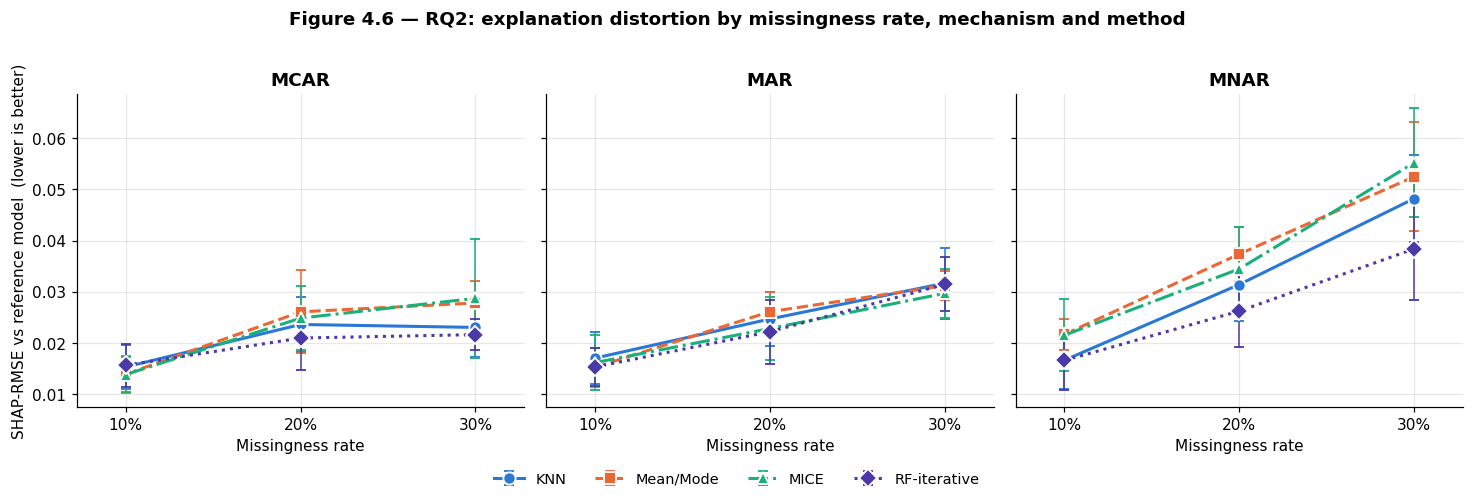

In [26]:
# Same chart format as Figure 4.5, so the two can be placed side by side in the Results
# chapter: reconstruction error (RQ1) and explanation distortion (RQ2) over the same grid.
small_multiples_by_mechanism(
    rq2_summary, "shap_rmse_mean", "shap_rmse_sd",
    "SHAP-RMSE vs reference model  (lower is better)",
    "Figure 4.6 — RQ2: explanation distortion by missingness rate, mechanism and method",
    "fig_4_6_rq2_shap_rmse_by_mechanism.png")

## 5.6 — RQ2 statistical evaluation

In [27]:
METRICS_RQ2 = ["shap_rmse", "lime_mean_rho"]

rq2_friedman = friedman_table(cleveland_rq2, METRICS_RQ2)
rq2_wilcoxon = wilcoxon_table(cleveland_rq2, rq2_friedman, METRICS_RQ2)

rq2_friedman.to_csv(OUT_TABLES / "table_rq2_friedman_results.csv", index=False)
rq2_wilcoxon.to_csv(OUT_TABLES / "table_rq2_wilcoxon_posthoc.csv", index=False)

print(f"Friedman: {len(rq2_friedman)} families, {int((rq2_friedman.p < 0.05).sum())} significant at p<.05")
print(f"Wilcoxon: {len(rq2_wilcoxon)} pairwise tests, "
      f"{int((rq2_wilcoxon.adjusted_p < 0.05).sum())} significant after Bonferroni")
rq2_friedman

Friedman: 18 families, 7 significant at p<.05
Wilcoxon: 42 pairwise tests, 12 significant after Bonferroni


,mechanism,rate,metric,chi_square,p,kendalls_w
0,MCAR,0.1,shap_rmse,3.15,0.369071,0.13125
1,MCAR,0.1,lime_mean_rho,1.35,0.717296,0.05625
2,MCAR,0.2,shap_rmse,3.75,0.289756,0.15625
3,MCAR,0.2,lime_mean_rho,0.75,0.861385,0.03125
4,MCAR,0.3,shap_rmse,8.70,0.033557,0.36250
5,MCAR,0.3,lime_mean_rho,1.80,0.614935,0.07500
6,MAR,0.1,shap_rmse,1.95,0.582849,0.08125
7,MAR,0.1,lime_mean_rho,3.75,0.289756,0.15625
8,MAR,0.2,shap_rmse,4.80,0.187042,0.20000
9,MAR,0.2,lime_mean_rho,8.85,0.031353,0.36875


## 5.7 — Figure 4.6b: LIME rank-agreement by rate, mechanism and method

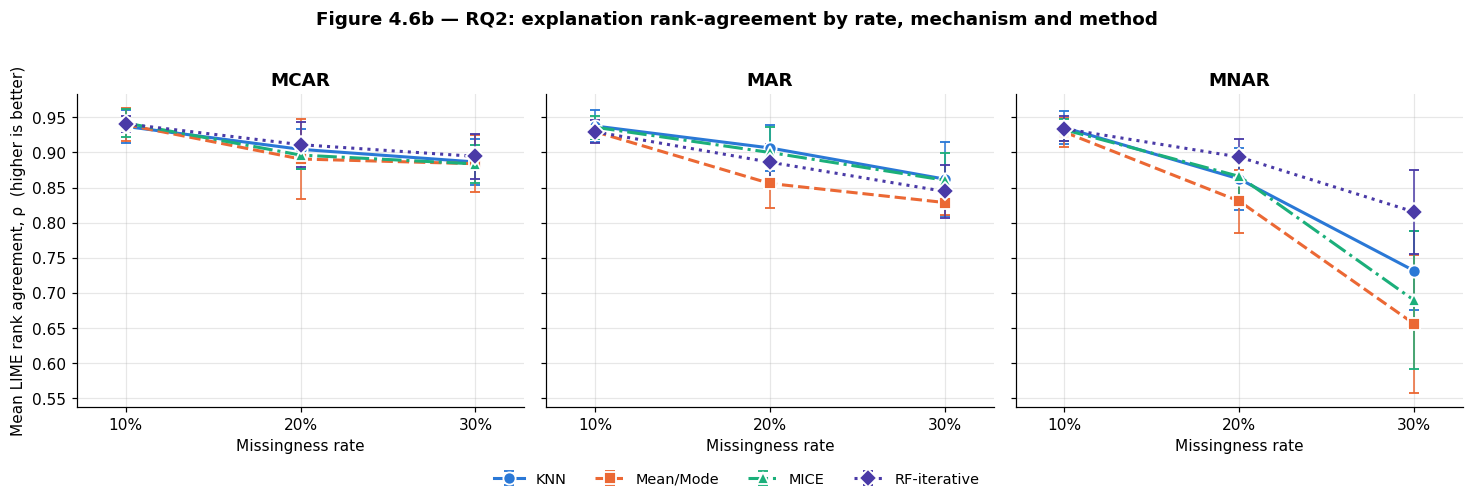

In [28]:
small_multiples_by_mechanism(
    rq2_summary, "lime_mean_rho_mean", "lime_mean_rho_sd",
    "Mean LIME rank agreement, ρ  (higher is better)",
    "Figure 4.6b — RQ2: explanation rank-agreement by rate, mechanism and method",
    "fig_4_6b_rq2_lime_rho_by_mechanism.png")


## 5.8 — O3: is the most accurate reconstruction method also the most explanation-stable one?  *(Table 4.3)*

In [29]:
rows = []
for mech in MECHANISMS:
    for rate in RATES:
        r1 = rq1_summary[(rq1_summary.mechanism == mech) & (rq1_summary.rate == rate)]
        r2 = rq2_summary[(rq2_summary.mechanism == mech) & (rq2_summary.rate == rate)]
        best_nrmse = r1.loc[r1.nrmse_mean.idxmin(), "method"]
        best_pfc   = r1.loc[r1.pfc_mean.idxmin(), "method"]
        best_shap  = r2.loc[r2.shap_rmse_mean.idxmin(), "method"]
        best_lime  = r2.loc[r2.lime_mean_rho_mean.idxmax(), "method"]
        winners = {best_nrmse, best_pfc, best_shap, best_lime}
        rows.append({
            "mechanism": mech, "rate": rate,
            "best_reconstruction_NRMSE": best_nrmse, "best_reconstruction_PFC": best_pfc,
            "best_explanation_SHAP_RMSE": best_shap, "best_explanation_LIME_rho": best_lime,
            "n_distinct_winners": len(winners),
            "accuracy_and_stability_agree": len(winners) == 1,
        })
table_4_3 = pd.DataFrame(rows)
table_4_3.to_csv(OUT_TABLES / "table_4_3_o3_accuracy_vs_stability.csv", index=False)

n_agree = int(table_4_3["accuracy_and_stability_agree"].sum())
print(f"O3: the most accurate reconstruction method was ALSO the most explanation-stable method "
      f"in {n_agree} of {len(table_4_3)} conditions.")

# Quantify O3 more precisely: rank correlation between RQ1 accuracy rank and RQ2 stability rank,
# across every (method x condition) combination rather than just counting outright wins.
rank_rows = []
for mech in MECHANISMS:
    for rate in RATES:
        r1 = rq1_summary[(rq1_summary.mechanism == mech) & (rq1_summary.rate == rate)].set_index("method")
        r2 = rq2_summary[(rq2_summary.mechanism == mech) & (rq2_summary.rate == rate)].set_index("method")
        nrmse_rank = r1.loc[METHOD_ORDER, "nrmse_mean"].rank()
        shap_rank  = r2.loc[METHOD_ORDER, "shap_rmse_mean"].rank()
        for m in METHOD_ORDER:
            rank_rows.append({"mechanism": mech, "rate": rate, "method": m,
                               "nrmse_rank": nrmse_rank[m], "shap_rmse_rank": shap_rank[m]})
rank_df = pd.DataFrame(rank_rows)
o3_rho, o3_p = spearmanr(rank_df["nrmse_rank"], rank_df["shap_rmse_rank"])
print(f"Spearman correlation between RQ1 accuracy rank and RQ2 explanation-stability rank, "
      f"across all {len(rank_df)} method x condition pairs: rho={o3_rho:.3f}, p={o3_p:.4f}")

table_4_3


O3: the most accurate reconstruction method was ALSO the most explanation-stable method in 2 of 9 conditions.
Spearman correlation between RQ1 accuracy rank and RQ2 explanation-stability rank, across all 36 method x condition pairs: rho=0.200, p=0.2422


,mechanism,rate,best_reconstruction_NRMSE,best_reconstruction_PFC,best_explanation_SHAP_RMSE,best_explanation_LIME_rho,n_distinct_winners,accuracy_and_stability_agree
0,MCAR,0.1,MICE,Mean/Mode,MICE,MICE,2,False
1,MCAR,0.2,MICE,Mean/Mode,RF-iterative,RF-iterative,3,False
2,MCAR,0.3,MICE,Mean/Mode,RF-iterative,RF-iterative,3,False
3,MAR,0.1,MICE,Mean/Mode,Mean/Mode,KNN,3,False
4,MAR,0.2,MICE,Mean/Mode,RF-iterative,KNN,4,False
5,MAR,0.3,MICE,Mean/Mode,MICE,KNN,3,False
6,MNAR,0.1,MICE,KNN,RF-iterative,KNN,3,False
7,MNAR,0.2,RF-iterative,RF-iterative,RF-iterative,RF-iterative,1,True
8,MNAR,0.3,RF-iterative,RF-iterative,RF-iterative,RF-iterative,1,True


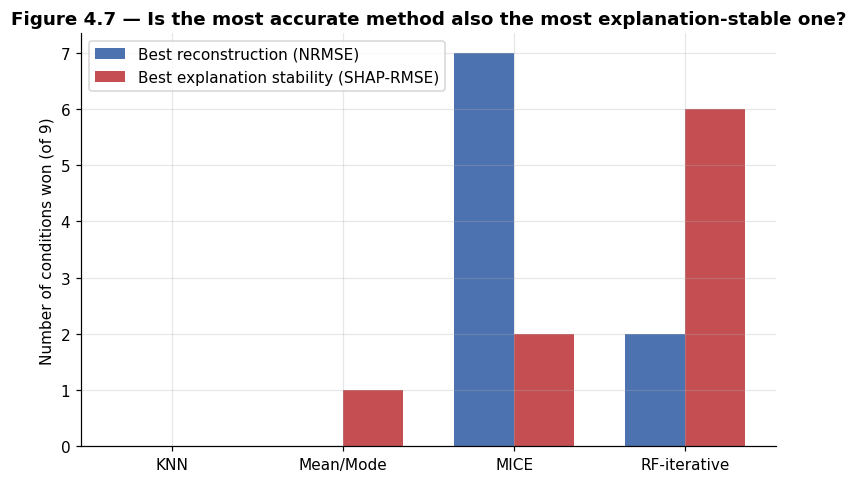

In [30]:
win_counts = pd.DataFrame({
    "Best reconstruction (NRMSE)": table_4_3["best_reconstruction_NRMSE"].value_counts(),
    "Best explanation stability (SHAP-RMSE)": table_4_3["best_explanation_SHAP_RMSE"].value_counts(),
}).reindex(METHOD_ORDER).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(METHOD_ORDER)); width = 0.35
ax.bar(x - width/2, win_counts["Best reconstruction (NRMSE)"], width,
       label="Best reconstruction (NRMSE)", color="#4c72b0")
ax.bar(x + width/2, win_counts["Best explanation stability (SHAP-RMSE)"], width,
       label="Best explanation stability (SHAP-RMSE)", color="#c44e52")
ax.set_xticks(x); ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Number of conditions won (of 9)")
ax.set_title("Figure 4.7 — Is the most accurate method also the most explanation-stable one?",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_4_7_o3_accuracy_vs_stability.png")
plt.show()


---
# STEP 6 — RQ2 on VA Long Beach: leakage-corrected predictive validation

In [31]:
va = pd.read_csv(DATA_CLEAN / "va_clean.csv")

EXCLUDED       = ["ca", "thal"]                                    # >=80% missing in VA
CATEGORICAL_VA = [c for c in CATEGORICAL if c not in EXCLUDED]
FEATURES_VA    = CONTINUOUS + CATEGORICAL_VA

X_raw = va[FEATURES_VA].copy()      # ORIGINAL naturally-missing matrix -- never pre-imputed
y_va  = va[TARGET].to_numpy()


def fit_transform_fold(method, X_train, X_val, seed):
    """Fit the named imputer using ONLY X_train, then transform both X_train and X_val with
    that SAME fitted imputer. X_val is never used for fitting, at any step."""
    domains = {c: np.sort(X_train[c].dropna().unique()) for c in CATEGORICAL_VA}

    if method == "KNN":
        scaler = StandardScaler().fit(X_train)
        train_scaled, val_scaled = scaler.transform(X_train), scaler.transform(X_val)
        imputer = KNNImputer(n_neighbors=5).fit(train_scaled)
        train_imp = pd.DataFrame(scaler.inverse_transform(imputer.transform(train_scaled)),
                                 columns=X_train.columns, index=X_train.index)
        val_imp = pd.DataFrame(scaler.inverse_transform(imputer.transform(val_scaled)),
                               columns=X_val.columns, index=X_val.index)
        return (snap_categoricals(train_imp, domains, CATEGORICAL_VA),
                snap_categoricals(val_imp, domains, CATEGORICAL_VA))

    if method == "Mean/Mode":
        imp_cont = SimpleImputer(strategy="mean").fit(X_train[CONTINUOUS])
        imp_cat  = SimpleImputer(strategy="most_frequent").fit(X_train[CATEGORICAL_VA])
        train_imp, val_imp = X_train.copy(), X_val.copy()
        train_imp[CONTINUOUS]     = imp_cont.transform(X_train[CONTINUOUS])
        val_imp[CONTINUOUS]       = imp_cont.transform(X_val[CONTINUOUS])
        train_imp[CATEGORICAL_VA] = imp_cat.transform(X_train[CATEGORICAL_VA])
        val_imp[CATEGORICAL_VA]   = imp_cat.transform(X_val[CATEGORICAL_VA])
        return train_imp, val_imp

    if method == "MICE":
        imp = IterativeImputer(estimator=BayesianRidge(), max_iter=10,
                               random_state=seed, sample_posterior=False).fit(X_train)
    elif method == "RF-iterative":
        rf = RandomForestRegressor(n_estimators=100, max_depth=None, n_jobs=-1, random_state=seed)
        imp = IterativeImputer(estimator=rf, max_iter=5, random_state=seed).fit(X_train)
    else:
        raise ValueError(f"Unknown method {method}")

    train_imp = pd.DataFrame(imp.transform(X_train), columns=X_train.columns, index=X_train.index)
    val_imp   = pd.DataFrame(imp.transform(X_val),   columns=X_val.columns,   index=X_val.index)
    return (snap_categoricals(train_imp, domains, CATEGORICAL_VA),
            snap_categoricals(val_imp, domains, CATEGORICAL_VA))


print(f"VA predictor matrix: {X_raw.shape} (excluded {EXCLUDED}, retained slope)")
print(f"Missing cells to impute: {int(X_raw.isna().sum().sum())}")

VA predictor matrix: (200, 11) (excluded ['ca', 'thal'], retained slope)
Missing cells to impute: 384


In [32]:
# One shared fold structure, reused identically by all four methods
fold_splits = list(StratifiedKFold(n_splits=5, shuffle=True,
                                   random_state=VA_SEED).split(X_raw, y_va))

va_cv_rows = []
for method in METHOD_ORDER:
    for fold_i, (tr, vl) in enumerate(fold_splits):
        X_tr, X_vl = X_raw.iloc[tr], X_raw.iloc[vl]
        y_tr, y_vl = y_va[tr], y_va[vl]

        train_imp, val_imp = fit_transform_fold(method, X_tr, X_vl, VA_SEED)

        clf = RandomForestClassifier(n_estimators=100, max_depth=None,
                                     n_jobs=-1, random_state=VA_SEED)
        clf.fit(train_imp.to_numpy(), y_tr)
        va_cv_rows.append({
            "method": method, "fold": fold_i, "n_train": len(tr), "n_val": len(vl),
            "auc": roc_auc_score(y_vl, clf.predict_proba(val_imp.to_numpy())[:, 1]),
            "accuracy": accuracy_score(y_vl, clf.predict(val_imp.to_numpy())),
            "imputer_fit_on": "train_fold_only",
        })

va_cv = pd.DataFrame(va_cv_rows)
va_cv_summary = va_cv.groupby("method", as_index=False).agg(
    auc_mean=("auc", "mean"), auc_sd=("auc", "std"),
    accuracy_mean=("accuracy", "mean"), accuracy_sd=("accuracy", "std"))

va_cv.to_csv(OUT_TABLES / "table_rq2_va_cv_results_leakage_corrected.csv", index=False)
va_cv_summary.to_csv(OUT_TABLES / "table_rq2_va_cv_summary_leakage_corrected.csv", index=False)
print(va_cv_summary.to_string(index=False))

      method  auc_mean   auc_sd  accuracy_mean  accuracy_sd
         KNN  0.671618 0.060616           0.76     0.060208
        MICE  0.652379 0.070160           0.79     0.013693
   Mean/Mode  0.662387 0.100183           0.78     0.020917
RF-iterative  0.629107 0.053142           0.74     0.028504


In [ ]:
# O4's "statistically indistinguishable" claim needs the same evidentiary standard used
# for RQ1/RQ2 on Cleveland (Friedman across methods, matched by fold) rather than eyeballing
# overlapping AUC/SD ranges.
va_auc_pivot = va_cv.pivot(index="fold", columns="method", values="auc")[METHOD_ORDER]
va_chi2, va_p = friedmanchisquare(*[va_auc_pivot[m].to_numpy() for m in METHOD_ORDER])
n_folds, n_methods = va_auc_pivot.shape
va_cv_friedman = pd.DataFrame([{
    "n_folds": n_folds, "n_methods": n_methods,
    "chi_square": va_chi2, "p": va_p,
    "kendalls_w": va_chi2 / (n_folds * (n_methods - 1)),
}])
va_cv_friedman.to_csv(OUT_TABLES / "table_rq2_va_cv_friedman.csv", index=False)
print(f"Friedman test, VA CV AUC across {n_methods} methods ({n_folds} matched folds): "
      f"chi2({n_methods - 1})={va_chi2:.3f}, p={va_p:.4f}, Kendall's W={va_chi2 / (n_folds * (n_methods - 1)):.3f}")


Friedman test, VA CV AUC across 4 methods (5 matched folds): chi2(3)=0.360, p=0.9484, Kendall's W=0.024


---
# STEP 7 — RQ2 on VA Long Beach: explanation agreement (not fidelity)

In [33]:
domains_all_va = {c: np.sort(X_raw[c].dropna().unique()) for c in CATEGORICAL_VA}


def impute_all_va(method, df, seed):
    """Whole-dataset imputation of the 200 VA patients -- explanation input only, not for CV."""
    if method == "Mean/Mode":
        out = df.copy()
        out[CONTINUOUS]     = SimpleImputer(strategy="mean").fit_transform(df[CONTINUOUS])
        out[CATEGORICAL_VA] = SimpleImputer(strategy="most_frequent").fit_transform(df[CATEGORICAL_VA])
        return out
    if method == "KNN":
        scaler = StandardScaler()
        scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)
        arr = KNNImputer(n_neighbors=5).fit_transform(scaled)
        unscaled = pd.DataFrame(scaler.inverse_transform(arr), columns=df.columns, index=df.index)
        return snap_categoricals(unscaled, domains_all_va, CATEGORICAL_VA)
    if method == "MICE":
        imp = IterativeImputer(estimator=BayesianRidge(), max_iter=10,
                               random_state=seed, sample_posterior=False)
    elif method == "RF-iterative":
        rf = RandomForestRegressor(n_estimators=100, max_depth=None, n_jobs=-1, random_state=seed)
        imp = IterativeImputer(estimator=rf, max_iter=5, random_state=seed)
    else:
        raise ValueError(f"Unknown method {method}")
    arr = imp.fit_transform(df)
    return snap_categoricals(pd.DataFrame(arr, columns=df.columns, index=df.index),
                             domains_all_va, CATEGORICAL_VA)


imputed_va = {m: impute_all_va(m, X_raw, VA_SEED) for m in ["KNN", "Mean/Mode", "MICE", "RF-iterative"]}

expl_models_va, shap_norm_va = {}, {}
for method in METHOD_ORDER:
    clf = RandomForestClassifier(n_estimators=100, max_depth=None, n_jobs=-1, random_state=VA_SEED)
    clf.fit(imputed_va[method].to_numpy(), y_va)
    expl_models_va[method] = clf
    raw = global_shap_class1(clf, imputed_va[method].to_numpy())
    shap_norm_va[method] = raw / raw.sum()

print("VA explanation models fitted and SHAP vectors computed for all 4 methods.")

VA explanation models fitted and SHAP vectors computed for all 4 methods.


In [34]:
# One fresh LIME explainer per method, never shared (same isolation rule as Step 5.3)
lime_matrices_va = {}
for method in METHOD_ORDER:
    Xi = imputed_va[method].to_numpy()
    explainer = LimeTabularExplainer(
        Xi, feature_names=FEATURES_VA, class_names=["no_disease", "disease"],
        discretize_continuous=False, mode="classification", random_state=VA_SEED)
    lime_matrices_va[method] = lime_weight_matrix(
        explainer, expl_models_va[method], Xi, FEATURES_VA)

agreement_rows = []
for a, b in PAIRS:
    rhos = spearman_per_patient(lime_matrices_va[a], lime_matrices_va[b])
    valid = rhos[~np.isnan(rhos)]
    agreement_rows.append({
        "method_a": a, "method_b": b,
        "shap_rmse": float(np.sqrt(np.mean((shap_norm_va[a] - shap_norm_va[b]) ** 2))),
        "n_patients": len(rhos),
        "mean_rho":   float(np.mean(valid))   if len(valid) else None,
        "median_rho": float(np.median(valid)) if len(valid) else None,
        "n_valid": int(len(valid)), "n_invalid": int(len(rhos) - len(valid)),
    })

va_explanation_agreement = pd.DataFrame(agreement_rows)
va_explanation_agreement.to_csv(OUT_TABLES / "table_rq2_va_explanation_agreement.csv", index=False)
va_explanation_agreement

,method_a,method_b,shap_rmse,n_patients,mean_rho,median_rho,n_valid,n_invalid
0,KNN,Mean/Mode,0.020843,200,0.925636,0.927273,200,0
1,KNN,MICE,0.009048,200,0.961045,0.963636,200,0
2,KNN,RF-iterative,0.015101,200,0.930727,0.936364,200,0
3,Mean/Mode,MICE,0.014684,200,0.960955,0.963636,200,0
4,Mean/Mode,RF-iterative,0.023752,200,0.894727,0.900000,200,0
5,MICE,RF-iterative,0.013956,200,0.929182,0.931818,200,0


## 7.3 — VA results, visualised: predictive performance and explanation agreement by method

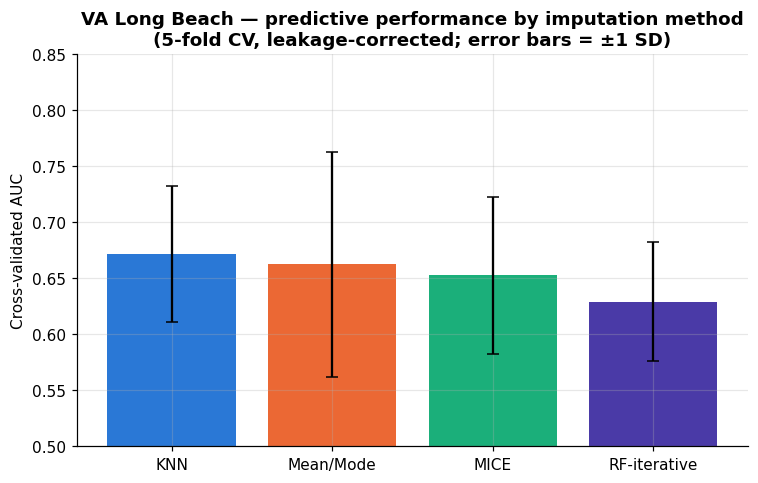

In [35]:
order = va_cv_summary.sort_values("auc_mean", ascending=False)["method"].tolist()
vals = va_cv_summary.set_index("method").loc[order]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(order, vals["auc_mean"], yerr=vals["auc_sd"], capsize=4,
       color=[METHOD_COLOUR[m] for m in order])
ax.set_ylabel("Cross-validated AUC")
ax.set_ylim(0.5, 0.85)
ax.set_title("VA Long Beach — predictive performance by imputation method\n"
             "(5-fold CV, leakage-corrected; error bars = ±1 SD)", fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_va_cv_auc_by_method.png")
plt.show()


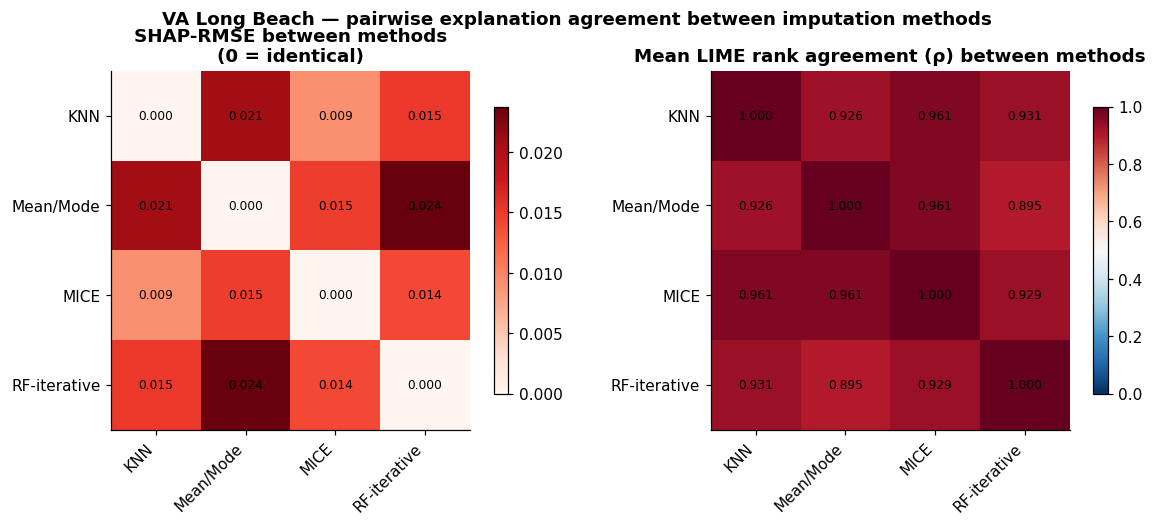

In [36]:
def to_symmetric_matrix(df, value_col, diag_value):
    mat = pd.DataFrame(diag_value, index=METHOD_ORDER, columns=METHOD_ORDER, dtype=float)
    for _, r in df.iterrows():
        mat.loc[r["method_a"], r["method_b"]] = r[value_col]
        mat.loc[r["method_b"], r["method_a"]] = r[value_col]
    return mat

shap_mat = to_symmetric_matrix(va_explanation_agreement, "shap_rmse", 0.0)
rho_mat  = to_symmetric_matrix(va_explanation_agreement, "mean_rho", 1.0)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, mat, title, cmap, vmax in [
    (axes[0], shap_mat, "SHAP-RMSE between methods\n(0 = identical)", "Reds", shap_mat.values.max()),
    (axes[1], rho_mat, "Mean LIME rank agreement (ρ) between methods", "RdBu_r", 1.0),
]:
    im = ax.imshow(mat.values, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(METHOD_ORDER))); ax.set_xticklabels(METHOD_ORDER, rotation=45, ha="right")
    ax.set_yticks(range(len(METHOD_ORDER))); ax.set_yticklabels(METHOD_ORDER)
    ax.grid(False)
    for i in range(len(METHOD_ORDER)):
        for j in range(len(METHOD_ORDER)):
            ax.text(j, i, f"{mat.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
    ax.set_title(title, fontweight="bold")
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("VA Long Beach — pairwise explanation agreement between imputation methods",
             fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "fig_va_explanation_agreement_heatmap.png")
plt.show()
